In [ ]:
# ===============================
# 0. Dependencies & Setup
# ===============================
import torch
import sys

TORCH_VER = torch.__version__

# Optional C++ extensions — skip gracefully if no matching wheel exists
try:
    import subprocess
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "torch_scatter", "torch_sparse", "torch_cluster", "torch_spline_conv",
        "-f", f"https://data.pyg.org/whl/torch-{TORCH_VER}.html"
    ], check=True)
    print("Optional PyG C++ extensions installed.")
except Exception as e:
    print(f"[INFO] Optional PyG C++ extensions unavailable (safe to ignore): {e}")

# Core required packages
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "torch_geometric", "matplotlib", "tqdm", "scikit-learn",
    "transformers", "librosa", "soundfile", "torchvision", "opencv-python-headless"],
    check=False)

import os
import json
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)

import matplotlib.pyplot as plt
from tqdm import tqdm

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
BASE_PATH     = '/content/drive/MyDrive/Multimodel_Sarcasm_Detection/'  # UPDATE to exact folder name

# MUStARD raw dataset paths
MUSTARD_JSON  = os.path.join(BASE_PATH, 'sarcasm_data.json')
UTTERANCE_DIR = os.path.join(BASE_PATH, 'Utterance/Utterance_Videos/')   # {id}.mp4
CONTEXT_DIR   = os.path.join(BASE_PATH, 'Context/Context_Videos/')     # {id}_c.mp4

# Pre-computed feature files (produced by extraction cells, loaded in Cell 8)
TEXT_FEAT     = 'text_features_imp.npy'
AUDIO_FEAT    = 'audio_features_imp.npy'
VIDEO_FEAT    = 'video_features_imp.npy'
CONTEXT_FEAT  = 'context_features_imp.npy'
LABELS_FEAT   = 'labels_imp.npy'
IDS_FEAT      = 'sample_ids_imp.npy'

# ── FFT-guided HuBERT audio config (identical to simple_fft notebook) ─────────
HUBERT_NAME  = 'facebook/hubert-large-ls960-ft'
HUBERT_DIM   = 1024
AUDIO_DIM    = HUBERT_DIM * 2   # 2048-d: focused(1024) + global(1024)
FFT_FEAT_DIR = os.path.join(BASE_PATH, 'features_fft/')
MAX_FRAMES   = 512               # max FFT weight frames stored per sample
FFT_TEMP     = 5.0               # temperature for softmax frame attention

# Training hyper-params
BATCH_SIZE    = 64
EPOCHS        = 100
LEARNING_RATE = 5e-5
WEIGHT_DECAY  = 1e-4
PATIENCE      = 10

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Optional PyG C++ extensions installed.
Using device: cuda


In [ ]:
# ===============================
# 1. Mount Google Drive
# ===============================
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [ ]:
# ===============================
# 2. Dataset Verification
#    Structure:
#      Utterance/{id}.mp4      — utterance video + audio
#      Context/{id}_c.mp4      — context  video + audio  (_c suffix)
#      sarcasm_data.json       — labels + utterance text
# ===============================

print('=' * 60)
print('MUSTARD DATASET VERIFICATION')
print('=' * 60)

# ── 2a. Check JSON ────────────────────────────────────────────────────────────
assert os.path.isfile(MUSTARD_JSON), f'JSON not found: {MUSTARD_JSON}'
with open(MUSTARD_JSON, 'r') as f:
    raw_data = json.load(f)

all_ids = list(raw_data.keys())
print(f'\n[JSON]  Loaded   : {len(all_ids)} entries from sarcasm_data.json')
print(f'        Sarcastic: {sum(1 for v in raw_data.values() if v["sarcasm"])}')
print(f'        Non-sarc : {sum(1 for v in raw_data.values() if not v["sarcasm"])}')

sample_key = all_ids[0]
print(f'\n[JSON]  Sample key      : {sample_key!r}')
print(f'        Fields          : {list(raw_data[sample_key].keys())}')
print(f'        Sample utterance: {str(raw_data[sample_key].get("utterance", "N/A"))[:80]}')

# ── 2b. Check folders ─────────────────────────────────────────────────────────
assert os.path.isdir(UTTERANCE_DIR), f'Utterance folder not found: {UTTERANCE_DIR}'
assert os.path.isdir(CONTEXT_DIR),   f'Context folder not found: {CONTEXT_DIR}'

utt_files = set(os.listdir(UTTERANCE_DIR))
ctx_files = set(os.listdir(CONTEXT_DIR))

print(f'\n[DIR]   Utterance/ : {len(utt_files)} files total')
print(f'[DIR]   Context/   : {len(ctx_files)} files total')

# ── 2c. Per-ID presence check ─────────────────────────────────────────────────
#        Utterance/{id}.mp4   vs   Context/{id}_c.mp4
status = {}
for uid in all_ids:
    status[uid] = {
        'utterance_video': f'{uid}.mp4'   in utt_files,
        'context_video'  : f'{uid}_c.mp4' in ctx_files,
    }

n_utt = sum(1 for s in status.values() if s['utterance_video'])
n_ctx = sum(1 for s in status.values() if s['context_video'])
n_all = sum(1 for s in status.values() if s['utterance_video'] and s['context_video'])

print('\n' + '-' * 60)
print('FILE PRESENCE COUNTS')
print(f'  Total entries in JSON           : {len(all_ids)}')
print(f'  Utterance/{"{id}"}.mp4 found    : {n_utt}')
print(f'  Context/{"{id}"}_c.mp4 found    : {n_ctx}')
print(f'  Fully linked (both present)     : {n_all}')
print(f'  Missing at least one modality   : {len(all_ids) - n_all}')

# ── 2d. Report missing files ──────────────────────────────────────────────────
missing_utt = [uid for uid, s in status.items() if not s['utterance_video']]
missing_ctx = [uid for uid, s in status.items() if not s['context_video']]

if missing_utt:
    print(f'\n[WARN]  {len(missing_utt)} utterance video(s) MISSING in Utterance/:')
    for uid in missing_utt[:10]: print(f'          {uid}.mp4')
    if len(missing_utt) > 10: print(f'          ... and {len(missing_utt)-10} more')
else:
    print('\n[OK]    All utterance videos present in Utterance/.')

if missing_ctx:
    print(f'\n[WARN]  {len(missing_ctx)} context video(s) MISSING in Context/:')
    for uid in missing_ctx[:10]: print(f'          {uid}_c.mp4')
    if len(missing_ctx) > 10: print(f'          ... and {len(missing_ctx)-10} more')
else:
    print('[OK]    All context videos present in Context/.')

# ── 2e. Build working set of fully-linked IDs ─────────────────────────────────
valid_ids = [
    uid for uid in all_ids
    if status[uid]['utterance_video'] and status[uid]['context_video']
]
print(f'\n[INFO]  Working set for feature extraction: {len(valid_ids)} samples')
print('=' * 60)

MUSTARD DATASET VERIFICATION

[JSON]  Loaded   : 690 entries from sarcasm_data.json
        Sarcastic: 345
        Non-sarc : 345

[JSON]  Sample key      : '1_60'
        Fields          : ['utterance', 'speaker', 'context', 'context_speakers', 'show', 'sarcasm']
        Sample utterance: It's just a privilege to watch your mind at work.

[DIR]   Utterance/ : 690 files total
[DIR]   Context/   : 690 files total

------------------------------------------------------------
FILE PRESENCE COUNTS
  Total entries in JSON           : 690
  Utterance/{id}.mp4 found    : 690
  Context/{id}_c.mp4 found    : 690
  Fully linked (both present)     : 690
  Missing at least one modality   : 0

[OK]    All utterance videos present in Utterance/.
[OK]    All context videos present in Context/.

[INFO]  Working set for feature extraction: 690 samples


In [ ]:
# ===============================
# 3. Check Pre-computed Features
#    Skip extraction if all .npy files already exist.
# ===============================

feat_files = {
    'text'   : os.path.join(BASE_PATH, TEXT_FEAT),
    'audio'  : os.path.join(BASE_PATH, AUDIO_FEAT),
    'video'  : os.path.join(BASE_PATH, VIDEO_FEAT),
    'context': os.path.join(BASE_PATH, CONTEXT_FEAT),
    'labels' : os.path.join(BASE_PATH, LABELS_FEAT),
}

feats_exist     = {k: os.path.isfile(v) for k, v in feat_files.items()}
all_feats_exist = all(feats_exist.values())

print('Feature file status:')
for name, path in feat_files.items():
    tick = '[OK]     ' if feats_exist[name] else '[MISSING]'
    print(f'  {tick}  {os.path.basename(path)}')

if all_feats_exist:
    print('\nAll feature files found — skipping extraction (jump to Cell 8).')
else:
    missing = [k for k, v in feats_exist.items() if not v]
    print(f'\nMissing: {missing}')
    print('Proceeding to feature extraction (Cells 4–7)...')

RUN_EXTRACTION = not all_feats_exist

Feature file status:
  [OK]       text_features_imp.npy
  [OK]       audio_features_imp.npy
  [OK]       video_features_imp.npy
  [OK]       context_features_imp.npy
  [OK]       labels_imp.npy

All feature files found — skipping extraction (jump to Cell 8).


In [ ]:
# ===============================
# 4. Text Feature Extraction
#    Model  : roberta-base  → 768-dim CLS token
#    Source : 'utterance' field in sarcasm_data.json
#    Output : text_features_imp.npy  (N × 768)
# ===============================

# ── Safety guard: rebuild valid_ids / raw_data if Cell 2 was skipped ──────────
if 'valid_ids' not in dir() or 'raw_data' not in dir():
    print("[INFO] valid_ids not in scope — rebuilding from sarcasm_data.json...")
    assert os.path.isfile(MUSTARD_JSON), f"JSON not found: {MUSTARD_JSON}"
    with open(MUSTARD_JSON, 'r') as f:
        raw_data = json.load(f)
    all_ids   = list(raw_data.keys())
    utt_files = set(os.listdir(UTTERANCE_DIR))
    ctx_files = set(os.listdir(CONTEXT_DIR))
    valid_ids = [
        uid for uid in all_ids
        if f'{uid}.mp4'   in utt_files
        and f'{uid}_c.mp4' in ctx_files
    ]
    print(f"[INFO] Rebuilt valid_ids: {len(valid_ids)} samples.")

if not RUN_EXTRACTION:
    print("Skipping text extraction (features already exist).")
else:
    import warnings
    warnings.filterwarnings("ignore")

    from transformers import RobertaTokenizer, RobertaModel, logging as hf_logging
    hf_logging.set_verbosity_error()

    print("Loading RoBERTa-base for text feature extraction...")
    tokenizer_txt = RobertaTokenizer.from_pretrained('roberta-base')
    model_txt     = RobertaModel.from_pretrained(
        'roberta-base', add_pooling_layer=False
    ).to(DEVICE)
    model_txt.eval()
    print(f"Model loaded. Extracting features for {len(valid_ids)} samples...")

    text_features = []

    with torch.no_grad():
        for uid in tqdm(valid_ids, desc='Text'):
            utterance_text = raw_data[uid]['utterance']
            enc = tokenizer_txt(
                utterance_text,
                return_tensors='pt',
                max_length=128,
                truncation=True,
                padding='max_length'
            ).to(DEVICE)
            out  = model_txt(**enc)
            feat = out.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()  # CLS → (768,)
            text_features.append(feat)

    text_features = np.array(text_features)   # (N, 768)
    np.save(os.path.join(BASE_PATH, TEXT_FEAT), text_features)
    print(f"Text features saved: {text_features.shape}  →  {TEXT_FEAT}")

    del model_txt, tokenizer_txt
    torch.cuda.empty_cache()

Skipping text extraction (features already exist).


In [ ]:
# ===============================
# 5. Audio Feature Extraction  (FFT-Guided HuBERT)
#    Utterance : Utterance/{id}.mp4  → FFT-weighted HuBERT-large → 2048-dim
#    Context   : Context/{id}_c.mp4  → FFT-weighted HuBERT-large → 2048-dim
#
#    FFT frame weights (identical to simple_fft notebook):
#      Pitch F0          weight 0.40
#      Spectral flux     weight 0.25
#      Spectral centroid weight 0.20
#      RMS energy        weight 0.15
#    Used as softmax attention over HuBERT hidden states.
#
#    Each output = concat([focused_1024, global_1024]) → 2048-d
#    Outputs:
#      audio_features_imp.npy       (N × 2048)  — utterance audio
#      audio_context_features.npy   (N × 2048)  — context   audio
# ===============================

# ── Safety guard ──────────────────────────────────────────────────────────────
if 'valid_ids' not in dir() or 'raw_data' not in dir():
    print("[INFO] valid_ids not in scope — rebuilding...")
    with open(MUSTARD_JSON, 'r') as f:
        raw_data = json.load(f)
    all_ids   = list(raw_data.keys())
    utt_files = set(os.listdir(UTTERANCE_DIR))
    ctx_files = set(os.listdir(CONTEXT_DIR))
    valid_ids = [
        uid for uid in all_ids
        if f'{uid}.mp4'   in utt_files
        and f'{uid}_c.mp4' in ctx_files
    ]
    print(f"[INFO] Rebuilt valid_ids: {len(valid_ids)} samples.")

if not RUN_EXTRACTION:
    print("Skipping audio extraction (features already exist).")
else:
    import io
    import librosa
    import soundfile as sf
    import subprocess as sp
    import tempfile
    import warnings
    warnings.filterwarnings("ignore")

    from transformers import HubertModel, Wav2Vec2FeatureExtractor, logging as hf_logging
    hf_logging.set_verbosity_error()

    os.makedirs(FFT_FEAT_DIR, exist_ok=True)

    SAMPLE_RATE = 16_000   # HuBERT expects 16 kHz

    # ── Step 1: Waveform extraction from video file ───────────────────────────
    def extract_wav_from_video(video_path: str, sr: int = SAMPLE_RATE) -> np.ndarray:
        """Extract mono waveform from an mp4/video file via ffmpeg."""
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            tmp_path = tmp.name
        sp.run(
            ['ffmpeg', '-y', '-i', video_path,
             '-ac', '1', '-ar', str(sr), '-vn', tmp_path],
            stdout=sp.DEVNULL, stderr=sp.DEVNULL, check=True
        )
        audio, _ = librosa.load(tmp_path, sr=sr, mono=True)
        os.remove(tmp_path)
        return audio.astype(np.float32)

    # ── Step 2: FFT-derived per-frame expressiveness weights ──────────────────
    # Identical to simple_fft notebook implementation.
    def get_sarcasm_frame_weights(y: np.ndarray, sr: int = SAMPLE_RATE,
                                   hop_length: int = 512) -> np.ndarray:
        """
        Compute per-frame expressiveness scores using FFT-derived features.
        Returns normalized weights (n_frames,) where high = likely sarcastic cue.
        """
        # 1. Pitch F0
        try:
            f0, _, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr, hop_length=hop_length)
            f0 = np.nan_to_num(f0, nan=0.0)
        except Exception:
            f0 = np.zeros(1 + len(y) // hop_length)

        # 2. RMS energy
        rms = librosa.feature.rms(y=y, hop_length=hop_length)[0]

        # 3. Spectral flux (FFT-based)
        stft = np.abs(librosa.stft(y, hop_length=hop_length, n_fft=1024))
        flux = np.sqrt(np.sum(np.diff(stft, axis=1) ** 2, axis=0))
        flux = np.pad(flux, (1, 0))

        # 4. Spectral centroid
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0]

        # Align all features to shortest length
        min_len = min(len(f0), len(rms), len(flux), len(centroid))
        f0, rms, flux, centroid = [x[:min_len] for x in [f0, rms, flux, centroid]]

        def norm01(x: np.ndarray) -> np.ndarray:
            r = x.max() - x.min()
            return (x - x.min()) / r if r > 1e-8 else np.zeros_like(x)

        score = (norm01(f0)       * 0.40 +
                 norm01(flux)     * 0.25 +
                 norm01(centroid) * 0.20 +
                 norm01(rms)      * 0.15)
        return score.astype(np.float32)

    # ── Step 3: Load HuBERT-large (frozen — used only for pre-extraction) ─────
    print("Loading HuBERT-large feature extractor...")
    hubert_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_NAME)

    print("Loading HuBERT-large model (frozen for pre-extraction)...")
    hubert_model = HubertModel.from_pretrained(HUBERT_NAME).float().to(DEVICE).eval()
    print("HuBERT loaded.")

    # ── Step 4: FFT-weighted HuBERT encoding — identical to simple_fft ────────
    @torch.no_grad()
    def extract_fft_audio(waveform: np.ndarray, fft_w: np.ndarray,
                           sr: int = SAMPLE_RATE):
        """
        FFT-weighted HuBERT encoding (identical to simple_fft notebook).
        Returns:
          focused (1024,) — FFT-attention-weighted mean of last 4 HuBERT layers
          global_ (1024,) — standard mean of last 4 HuBERT layers
        """
        inp = hubert_extractor(waveform, sampling_rate=sr,
                               return_tensors='pt', padding=True)
        wav_tensor = inp['input_values'].to(DEVICE)         # (1, T_wav)

        out   = hubert_model(wav_tensor, output_hidden_states=True)
        last4 = torch.stack(out.hidden_states[-4:]).mean(0) # (1, T_h, 1024)
        T_h   = last4.shape[1]

        # Interpolate FFT weights to match HuBERT time resolution
        fft_tensor  = torch.tensor(fft_w, dtype=torch.float32
                                   ).unsqueeze(0).unsqueeze(0).to(DEVICE)
        fft_aligned = F.interpolate(fft_tensor, size=T_h, mode='linear',
                                     align_corners=False).squeeze()        # (T_h,)

        # Softmax with temperature → per-frame attention weights
        attn = torch.softmax(fft_aligned * FFT_TEMP, dim=0)               # (T_h,)

        # Focused: FFT-attended weighted mean
        focused = (last4[0] * attn.unsqueeze(-1)).sum(0)                   # (1024,)

        # Global: standard unweighted mean
        global_ = last4[0].mean(0)                                         # (1024,)

        return focused.cpu().numpy(), global_.cpu().numpy()

    # ── Step 5: Quick FFT test on first sample ────────────────────────────────
    _test_path = os.path.join(UTTERANCE_DIR, f'{valid_ids[0]}.mp4')
    _y = extract_wav_from_video(_test_path)
    _w = get_sarcasm_frame_weights(_y, SAMPLE_RATE)
    print(f"\nFFT weight test:")
    print(f"  waveform       : {len(_y)} samples ({len(_y)/SAMPLE_RATE:.2f}s)")
    print(f"  frame weights  : {len(_w)} frames, "
          f"range=[{_w.min():.3f}, {_w.max():.3f}]")
    print(f"  high-score frames (>0.7): {(_w > 0.7).sum()}")
    del _y, _w

    # ── Step 6: Pre-extract FFT-weighted HuBERT for all samples ──────────────
    print(f"\nExtracting FFT-guided HuBERT features for {len(valid_ids)} samples...")
    print("(Utterance + Context — 2048-d each)")

    audio_utt_features = np.zeros((len(valid_ids), 2048), dtype=np.float32)
    audio_ctx_features = np.zeros((len(valid_ids), 2048), dtype=np.float32)

    for idx, uid in enumerate(tqdm(valid_ids, desc='FFT-HuBERT (utt + ctx)')):

        # ── Utterance audio: Utterance/{id}.mp4 ──────────────────────────────
        utt_path = os.path.join(UTTERANCE_DIR, f'{uid}.mp4')
        try:
            y_utt  = extract_wav_from_video(utt_path)
            w_utt  = get_sarcasm_frame_weights(y_utt, SAMPLE_RATE)
            # Pad/truncate to MAX_FRAMES before passing (interpolated inside)
            if len(w_utt) >= MAX_FRAMES:
                w_utt_fixed = w_utt[:MAX_FRAMES]
            else:
                w_utt_fixed = np.pad(w_utt, (0, MAX_FRAMES - len(w_utt)))
            focused_utt, global_utt = extract_fft_audio(y_utt, w_utt_fixed, SAMPLE_RATE)
            audio_utt_features[idx] = np.concatenate([focused_utt, global_utt])
        except Exception as e:
            print(f'[WARN] Audio utt failed for {uid}: {e}')
            # zero vector already in place

        # ── Context audio: Context/{id}_c.mp4 ────────────────────────────────
        ctx_path = os.path.join(CONTEXT_DIR, f'{uid}_c.mp4')
        try:
            y_ctx  = extract_wav_from_video(ctx_path)
            w_ctx  = get_sarcasm_frame_weights(y_ctx, SAMPLE_RATE)
            if len(w_ctx) >= MAX_FRAMES:
                w_ctx_fixed = w_ctx[:MAX_FRAMES]
            else:
                w_ctx_fixed = np.pad(w_ctx, (0, MAX_FRAMES - len(w_ctx)))
            focused_ctx, global_ctx = extract_fft_audio(y_ctx, w_ctx_fixed, SAMPLE_RATE)
            audio_ctx_features[idx] = np.concatenate([focused_ctx, global_ctx])
        except Exception as e:
            print(f'[WARN] Audio ctx failed for {uid}: {e}')
            # zero vector already in place

    np.save(os.path.join(BASE_PATH, AUDIO_FEAT),                 audio_utt_features)
    np.save(os.path.join(BASE_PATH, 'audio_context_features.npy'), audio_ctx_features)
    print(f"Utterance audio saved : {audio_utt_features.shape}  →  {AUDIO_FEAT}")
    print(f"Context   audio saved : {audio_ctx_features.shape}  →  audio_context_features.npy")

    # Free HuBERT from GPU — no longer needed after extraction
    del hubert_model, hubert_extractor
    torch.cuda.empty_cache()


Skipping audio extraction (features already exist).


In [ ]:
# ===============================
# 6. Video Feature Extraction
#    Utterance : Utterance/{id}.mp4     → ResNet-50 pool5 → 2048-dim
#    Context   : Context/{id}_c.mp4     → ResNet-50 pool5 → 2048-dim
#    Strategy  : uniformly sample 8 frames, mean-pool → (2048,) per clip
#    Outputs:
#      video_features_imp.npy       (N × 2048)  — utterance video
#      video_context_features.npy   (N × 2048)  — context   video
# ===============================

# ── Safety guard ──────────────────────────────────────────────────────────────
if 'valid_ids' not in dir() or 'raw_data' not in dir():
    print("[INFO] valid_ids not in scope — rebuilding...")
    with open(MUSTARD_JSON, 'r') as f:
        raw_data = json.load(f)
    all_ids   = list(raw_data.keys())
    utt_files = set(os.listdir(UTTERANCE_DIR))
    ctx_files = set(os.listdir(CONTEXT_DIR))
    valid_ids = [
        uid for uid in all_ids
        if f'{uid}.mp4'   in utt_files
        and f'{uid}_c.mp4' in ctx_files
    ]
    print(f"[INFO] Rebuilt valid_ids: {len(valid_ids)} samples.")

if not RUN_EXTRACTION:
    print("Skipping video extraction (features already exist).")
else:
    import cv2
    import torchvision.models as tvm
    import torchvision.transforms as tvt

    N_FRAMES = 8   # uniform frame samples per clip

    # ── ResNet-50 backbone (strip FC → pool5 = 2048-dim) ──────────────────────
    resnet         = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V1)
    video_backbone = nn.Sequential(*list(resnet.children())[:-1])   # up to AvgPool
    video_backbone = video_backbone.to(DEVICE).eval()

    video_transform = tvt.Compose([
        tvt.ToPILImage(),
        tvt.Resize((224, 224)),
        tvt.ToTensor(),
        tvt.Normalize(mean=[0.485, 0.456, 0.406],
                      std =[0.229, 0.224, 0.225]),
    ])

    def extract_video_feat(video_path: str, n_frames: int = N_FRAMES) -> np.ndarray:
        cap   = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release()
            return np.zeros(2048, dtype=np.float32)

        indices       = np.linspace(0, total - 1, n_frames, dtype=int)
        frame_tensors = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                continue
            frame_tensors.append(video_transform(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        cap.release()

        if not frame_tensors:
            return np.zeros(2048, dtype=np.float32)

        batch = torch.stack(frame_tensors).to(DEVICE)   # (n_frames, 3, 224, 224)
        with torch.no_grad():
            out = video_backbone(batch)                  # (n_frames, 2048, 1, 1)
        return out.squeeze(-1).squeeze(-1).mean(dim=0).cpu().numpy()   # (2048,)

    video_utt_features = []
    video_ctx_features = []

    print(f"Extracting video features for {len(valid_ids)} samples...")
    for uid in tqdm(valid_ids, desc='Video (utterance + context)'):
        # ── Utterance video:  Utterance/{id}.mp4
        utt_path = os.path.join(UTTERANCE_DIR, f'{uid}.mp4')
        try:
            feat_utt = extract_video_feat(utt_path)
        except Exception as e:
            print(f'[WARN] Video utt failed for {uid}: {e}')
            feat_utt = np.zeros(2048, dtype=np.float32)

        # ── Context video:  Context/{id}_c.mp4
        ctx_path = os.path.join(CONTEXT_DIR, f'{uid}_c.mp4')
        try:
            feat_ctx = extract_video_feat(ctx_path)
        except Exception as e:
            print(f'[WARN] Video ctx failed for {uid}: {e}')
            feat_ctx = np.zeros(2048, dtype=np.float32)

        video_utt_features.append(feat_utt)
        video_ctx_features.append(feat_ctx)

    video_utt_features = np.array(video_utt_features)   # (N, 2048)
    video_ctx_features = np.array(video_ctx_features)   # (N, 2048)

    np.save(os.path.join(BASE_PATH, VIDEO_FEAT),                video_utt_features)
    np.save(os.path.join(BASE_PATH, 'video_context_features.npy'), video_ctx_features)
    print(f"Utterance video saved : {video_utt_features.shape}  →  {VIDEO_FEAT}")
    print(f"Context   video saved : {video_ctx_features.shape}  →  video_context_features.npy")

    del video_backbone, resnet
    torch.cuda.empty_cache()

Skipping video extraction (features already exist).


In [ ]:
# ===============================
# 7. Combine Context Features & Save Labels
#    Context vector = concat(audio_context 2048 + video_context 2048) = 4096-dim
#    (audio_context is now FFT-guided HuBERT 2048-d, up from 768-d)
#    Outputs:
#      context_features_imp.npy   (N × 4096)
#      labels_imp.npy             (N,)  binary int
#      sample_ids_imp.npy         (N,)  utterance ID strings
# ===============================

# ── Safety guard ──────────────────────────────────────────────────────────────
if 'valid_ids' not in dir() or 'raw_data' not in dir():
    print("[INFO] valid_ids not in scope — rebuilding...")
    with open(MUSTARD_JSON, 'r') as f:
        raw_data = json.load(f)
    all_ids   = list(raw_data.keys())
    utt_files = set(os.listdir(UTTERANCE_DIR))
    ctx_files = set(os.listdir(CONTEXT_DIR))
    valid_ids = [
        uid for uid in all_ids
        if f'{uid}.mp4'   in utt_files
        and f'{uid}_c.mp4' in ctx_files
    ]
    print(f"[INFO] Rebuilt valid_ids: {len(valid_ids)} samples.")

if not RUN_EXTRACTION:
    print("Skipping context combination (features already exist).")
else:
    audio_ctx_feat = np.load(os.path.join(BASE_PATH, 'audio_context_features.npy'))
    video_ctx_feat = np.load(os.path.join(BASE_PATH, 'video_context_features.npy'))

    # Concatenate: 2048 (FFT-HuBERT audio) + 2048 (video) = 4096
    context_features = np.concatenate([audio_ctx_feat, video_ctx_feat], axis=1)
    print(f"Context features: {audio_ctx_feat.shape[1]} (FFT-HuBERT audio) + "
          f"{video_ctx_feat.shape[1]} (video) = {context_features.shape[1]}-dim")

    labels     = np.array([int(raw_data[uid]['sarcasm']) for uid in valid_ids], dtype=np.int64)
    sample_ids = np.array(valid_ids)

    np.save(os.path.join(BASE_PATH, CONTEXT_FEAT), context_features)
    np.save(os.path.join(BASE_PATH, LABELS_FEAT),  labels)
    np.save(os.path.join(BASE_PATH, IDS_FEAT),     sample_ids)

    print(f"\nContext features saved → {CONTEXT_FEAT}  shape: {context_features.shape}")
    print(f"Labels saved           → {LABELS_FEAT}   sarcastic={labels.sum()}  non-sarcastic={len(labels)-labels.sum()}")
    print(f"Sample IDs saved       → {IDS_FEAT}")

    print("\n── Feature Extraction Summary ──")
    print(f"  Text    : {np.load(os.path.join(BASE_PATH, TEXT_FEAT)).shape}")
    print(f"  Audio   : {np.load(os.path.join(BASE_PATH, AUDIO_FEAT)).shape}  ← FFT-HuBERT 2048-d")
    print(f"  Video   : {np.load(os.path.join(BASE_PATH, VIDEO_FEAT)).shape}")
    print(f"  Context : {context_features.shape}  ← FFT-audio 2048 + video 2048")
    print(f"  Labels  : {labels.shape}")


Skipping context combination (features already exist).


In [ ]:
# ===============================
# 8. Load Features
# ===============================
print("Loading All Features (Text, Audio, Video, Context)...")

t_features = np.load(os.path.join(BASE_PATH, TEXT_FEAT))
a_features = np.load(os.path.join(BASE_PATH, AUDIO_FEAT))
v_features = np.load(os.path.join(BASE_PATH, VIDEO_FEAT))
c_features = np.load(os.path.join(BASE_PATH, CONTEXT_FEAT))
labels     = np.load(os.path.join(BASE_PATH, LABELS_FEAT))

print(f"Loaded {len(labels)} samples.")
print(f"Dims: T={t_features.shape[1]}, A={a_features.shape[1]}, "
      f"V={v_features.shape[1]}, C={c_features.shape[1]}")

assert t_features.shape[0] == a_features.shape[0] ==        v_features.shape[0] == c_features.shape[0] == len(labels),        "Shape mismatch across feature files!"
print("Shape consistency check: PASSED")

Loading All Features (Text, Audio, Video, Context)...
Loaded 690 samples.
Dims: T=768, A=2048, V=2048, C=4096
Shape consistency check: PASSED


In [ ]:
# ===============================
# 9. Build Graph Dataset
#    Nodes: 0=Text, 1=Audio, 2=Video, 3=Context
#    Edges: modality triangle + context star + self-loops
# ===============================
data_list = []
for i in range(len(labels)):
    t = torch.tensor(t_features[i], dtype=torch.float).unsqueeze(0)
    a = torch.tensor(a_features[i], dtype=torch.float).unsqueeze(0)
    v = torch.tensor(v_features[i], dtype=torch.float).unsqueeze(0)
    c = torch.tensor(c_features[i], dtype=torch.float).unsqueeze(0)
    y = torch.tensor([labels[i]], dtype=torch.float)

    edge_index = torch.tensor([
        [0,1],[1,0], [0,2],[2,0], [1,2],[2,1],  # Modality triangle
        [3,0],[0,3], [3,1],[1,3], [3,2],[2,3],  # Context star
        [0,0],[1,1],[2,2],[3,3]                 # Self loops
    ], dtype=torch.long).t().contiguous()

    data           = Data(edge_index=edge_index, y=y)
    data.text      = t
    data.audio     = a
    data.video     = v
    data.context   = c
    data.num_nodes = 4

    data_list.append(data)

print(f"Built {len(data_list)} graph samples.")

Built 690 graph samples.


In [ ]:
# ===============================
# 10. Train / Val / Test Split  (~70 / 15 / 15)
# ===============================
train_val, test = train_test_split(
    data_list, test_size=0.15, random_state=42, stratify=labels
)

labels_train_val = np.array([d.y.item() for d in train_val])
train, val = train_test_split(
    train_val, test_size=0.1765, random_state=42, stratify=labels_train_val
)  # 0.1765 * 0.85 ≈ 0.15

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test,  batch_size=BATCH_SIZE, shuffle=False)

Train: 482, Val: 104, Test: 104


In [ ]:
# ===============================
# 11. SarcasmGATv2 Model
# ===============================
class SarcasmGATv2(nn.Module):
    def __init__(self, t_dim, a_dim, v_dim, c_dim,
                 hidden_dim=256, gat_dropout=0.6, fc_dropout=0.6):
        super().__init__()

        # Modality projections
        self.p_t = nn.Sequential(nn.Linear(t_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.p_a = nn.Sequential(nn.Linear(a_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.p_v = nn.Sequential(nn.Linear(v_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.p_c = nn.Sequential(nn.Linear(c_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())

        # GATv2 layers
        self.gat1 = GATv2Conv(hidden_dim,     hidden_dim, heads=8, concat=True,  dropout=gat_dropout)
        self.gat2 = GATv2Conv(hidden_dim * 8, hidden_dim, heads=1, concat=False, dropout=gat_dropout)

        # Classifier head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(fc_dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data):
        x_t = self.p_t(data.text)
        x_a = self.p_a(data.audio)
        x_v = self.p_v(data.video)
        x_c = self.p_c(data.context)

        batch_size = x_t.size(0)
        d          = x_t.size(1)

        x = torch.zeros(batch_size * 4, d, device=DEVICE)
        x[0::4] = x_t
        x[1::4] = x_a
        x[2::4] = x_v
        x[3::4] = x_c

        base_edges      = data.edge_index[:, :16]
        edge_index_list = [base_edges + i * 4 for i in range(batch_size)]
        edge_index      = torch.cat(edge_index_list, dim=1).to(DEVICE)

        out = F.gelu(self.gat1(x, edge_index))
        out = self.gat2(out, edge_index)

        batch_vec = torch.arange(batch_size, device=DEVICE).view(-1, 1).repeat(1, 4).view(-1)
        out       = global_mean_pool(out, batch_vec)

        return self.fc(out).squeeze(-1)

In [ ]:
# ===============================
# 12. Optimizer, Scheduler, Loss
# ===============================

# ── Full reproducibility ──────────────────────────────────────────────────────
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
# ─────────────────────────────────────────────────────────────────────────────

model = SarcasmGATv2(
    t_dim=t_features.shape[1],
    a_dim=a_features.shape[1],
    v_dim=v_features.shape[1],
    c_dim=c_features.shape[1],
    hidden_dim=256,
    gat_dropout=0.6,
    fc_dropout=0.6,
).to(DEVICE)

decay_params, no_decay_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if any(nd in name for nd in ['bias', 'LayerNorm']):
        no_decay_params.append(param)
    else:
        decay_params.append(param)

optimizer = torch.optim.AdamW(
    [
        {'params': decay_params,    'weight_decay': WEIGHT_DECAY},
        {'params': no_decay_params, 'weight_decay': 0.0},
    ],
    lr=LEARNING_RATE,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2
)

criterion = nn.BCEWithLogitsLoss()
print("Model, optimizer, scheduler and loss function ready.")

Model, optimizer, scheduler and loss function ready.


In [ ]:
# ===============================
# 13. Train / Eval Functions
# ===============================
def train_one_epoch(loader):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for data in loader:
        data   = data.to(DEVICE)
        optimizer.zero_grad()
        logits = model(data)
        loss   = criterion(logits, data.y.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.y.size(0)
        probs  = torch.sigmoid(logits).detach().cpu().numpy()
        preds  = (probs >= 0.5).astype(int)
        lbls   = data.y.view(-1).cpu().numpy().astype(int)
        all_preds.extend(preds)
        all_labels.extend(lbls)

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for data in loader:
        data   = data.to(DEVICE)
        logits = model(data)
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= 0.5).astype(int)
        lbls   = data.y.view(-1).cpu().numpy().astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(lbls.tolist())

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds,   average='macro')
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds,    average='macro', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')
    return acc, f1, prec, rec, auc

Epoch 001 | Train Loss 0.6949 Acc 0.4979 F1 0.4611 | Val Acc 0.5192 F1 0.3747 Prec 0.7549 Rec 0.5192 AUC 0.6435 | LR 0.000049
Epoch 002 | Train Loss 0.6902 Acc 0.5415 F1 0.5413 | Val Acc 0.5769 F1 0.5385 Prec 0.6153 Rec 0.5769 AUC 0.6836 | LR 0.000045
Epoch 003 | Train Loss 0.6899 Acc 0.5477 F1 0.5415 | Val Acc 0.5000 F1 0.3333 Prec 0.2500 Rec 0.5000 AUC 0.7089 | LR 0.000040
Epoch 004 | Train Loss 0.6861 Acc 0.5622 F1 0.5514 | Val Acc 0.5865 F1 0.5690 Prec 0.6034 Rec 0.5865 AUC 0.7341 | LR 0.000033
Epoch 005 | Train Loss 0.6799 Acc 0.6162 F1 0.6161 | Val Acc 0.6731 F1 0.6700 Prec 0.6797 Rec 0.6731 AUC 0.7478 | LR 0.000025
Epoch 006 | Train Loss 0.6761 Acc 0.5934 F1 0.5933 | Val Acc 0.6635 F1 0.6634 Prec 0.6635 Rec 0.6635 AUC 0.7607 | LR 0.000017
Epoch 007 | Train Loss 0.6678 Acc 0.6660 F1 0.6660 | Val Acc 0.7019 F1 0.7012 Prec 0.7038 Rec 0.7019 AUC 0.7733 | LR 0.000010
Epoch 008 | Train Loss 0.6598 Acc 0.6846 F1 0.6846 | Val Acc 0.6538 F1 0.6492 Prec 0.6625 Rec 0.6538 AUC 0.7755 | LR 0

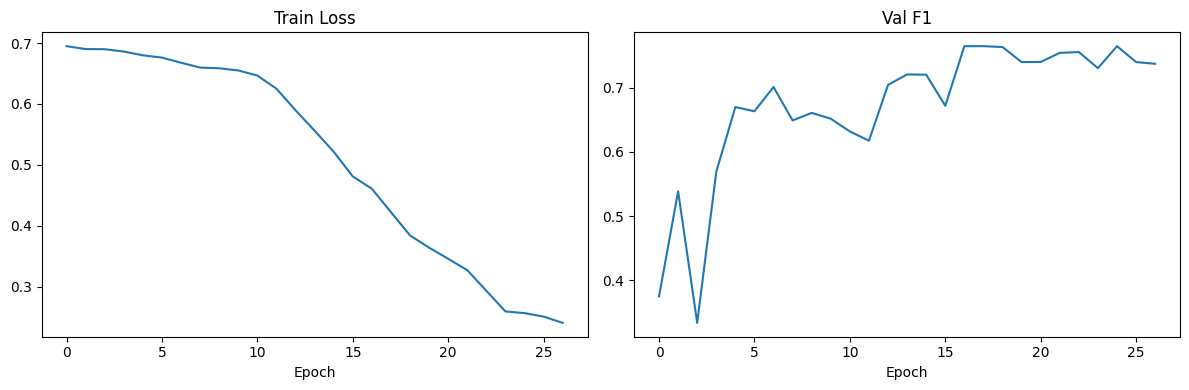

In [ ]:
# ===============================
# 14. Training Loop with Early Stopping
# ===============================

# ── Re-seed before training to ensure shuffle reproducibility ─────────────────
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)
# ─────────────────────────────────────────────────────────────────────────────

best_val_f1      = 0.0
best_state       = None
patience_counter = 0
train_losses, val_f1s = [], []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1             = train_one_epoch(train_loader)
    val_acc, val_f1, val_prec, val_rec, val_auc = evaluate(val_loader)

    scheduler.step(epoch)
    train_losses.append(train_loss)
    val_f1s.append(val_f1)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} F1 {train_f1:.4f} | "
        f"Val Acc {val_acc:.4f} F1 {val_f1:.4f} Prec {val_prec:.4f} "
        f"Rec {val_rec:.4f} AUC {val_auc:.4f} | "
        f"LR {optimizer.param_groups[0]['lr']:.6f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        best_state       = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print(f"Training complete. Best Val F1: {best_val_f1:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), os.path.join(BASE_PATH, 'best_sarcasm_gatv2_full.pth'))
    print("Best model saved.")

# ── Plot training curves ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses); ax1.set_title('Train Loss'); ax1.set_xlabel('Epoch')
ax2.plot(val_f1s);      ax2.set_title('Val F1');     ax2.set_xlabel('Epoch')
plt.tight_layout()
try:
    plt.savefig(os.path.join(BASE_PATH, 'training_curves.png'), dpi=150)
except Exception as _e:
    print(f'[WARN] Could not save plot (Drive disconnected?): {_e}')
plt.show()

In [ ]:
# ===============================
# 15. Final Test Evaluation
# ===============================
test_acc, test_f1, test_prec, test_rec, test_auc = evaluate(test_loader)
print(f"TEST | Acc {test_acc:.4f}  F1 {test_f1:.4f}  "
      f"Prec {test_prec:.4f}  Rec {test_rec:.4f}  AUC {test_auc:.4f}")

TEST | Acc 0.7788  F1 0.7778  Prec 0.7840  Rec 0.7788  AUC 0.8369


In [ ]:
# ===============================
# 16. Install Optuna
# ===============================
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"], check=False)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"Optuna {optuna.__version__} ready.")


Optuna 4.8.0 ready.


In [ ]:
# ===============================
# 17. Hyperparameter Tuning Config
#
#  YOUR BASELINE (TEST scores from Cell 15):
#    Acc 0.7788 | F1 0.7787 | Prec 0.7798 | Rec 0.7788 | AUC 0.8147
#
#  Current config:
#    hidden_dim=256  gat_heads=8  gat_dropout=0.60  fc_dropout=0.60
#    fc_hidden=128   lr=5e-5      weight_decay=1e-4  T_0=10  T_mult=2
#    batch_size=64   label_smoothing=0.0  grad_clip=none
#
#  Observations from your scores:
#    - Prec (0.7798) ≈ Rec (0.7788)  →  model is balanced, not biased
#    - AUC (0.8147) has room to grow  →  ranking/calibration needs work
#    - F1 (0.7787) close to Acc       →  class balance is good
#
#  HPO targets (150 trials, 80 epochs each):
#    1. dropout         0.10-0.55   (0.60 too aggressive for 482 samples)
#    2. lr              1e-5-3e-4   (nudge up from 5e-5)
#    3. label_smoothing 0.00-0.15   (calibration fix — lifts AUC)
#    4. grad_clip       0.5/1/2/5   (was missing — stabilises GATv2)
#    5. hidden_dim      192-512     (256 may be underfitting)
#    6. fc_hidden       128-256     (more capacity in classifier head)
#    7. batch_size      16/32/64    (smaller = noisier grad = better on small data)
#    8. weight_decay    1e-5-1e-2   (wider range)
#    9. T_0             10-25       (longer warmup cycles)
#   10. T_mult          1 or 2      (uniform vs expanding cosine cycles)
# ===============================

HT_N_TRIALS  = 150
HT_EPOCHS    = 80
HT_PATIENCE  = 15
HT_SEED      = 42

print(f"HPO config ready.")
print(f"  Trials    : {HT_N_TRIALS}")
print(f"  Epochs    : up to {HT_EPOCHS} per trial  (patience {HT_PATIENCE})")
print(f"  Baseline  : Acc 0.7788 | F1 0.7787 | Prec 0.7798 | Rec 0.7788 | AUC 0.8147")
print(f"  Target    : F1 > 0.7900 | AUC > 0.8400")
print(f"  Est. time : ~60-90 min (T4)  |  ~30-45 min (A100)")

HPO config ready.
  Trials    : 150
  Epochs    : up to 80 per trial  (patience 15)
  Baseline  : Acc 0.7788 | F1 0.7787 | Prec 0.7798 | Rec 0.7788 | AUC 0.8147
  Target    : F1 > 0.7900 | AUC > 0.8400
  Est. time : ~60-90 min (T4)  |  ~30-45 min (A100)


In [ ]:
# ===============================
# 18. Optuna Objective & Study
# ===============================
import optuna, copy
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
from torch_geometric.nn    import GATv2Conv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.data   import Data as _Data
from sklearn.model_selection import train_test_split as _tts
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score, roc_auc_score)

# ── Always rebuild dedicated HPO splits (never rely on global scope) ──────────
print("[INFO] Building HPO splits from saved .npy features...")
_tf = np.load(os.path.join(BASE_PATH, TEXT_FEAT))
_af = np.load(os.path.join(BASE_PATH, AUDIO_FEAT))
_vf = np.load(os.path.join(BASE_PATH, VIDEO_FEAT))
_cf = np.load(os.path.join(BASE_PATH, CONTEXT_FEAT))
_lb = np.load(os.path.join(BASE_PATH, LABELS_FEAT))

t_features = _tf; a_features = _af
v_features = _vf; c_features = _cf

_dlist = []
for _i in range(len(_lb)):
    _ei = torch.tensor([
        [0,1],[1,0],[0,2],[2,0],[1,2],[2,1],
        [3,0],[0,3],[3,1],[1,3],[3,2],[2,3],
        [0,0],[1,1],[2,2],[3,3]
    ], dtype=torch.long).t().contiguous()
    _d = _Data(edge_index=_ei,
               y=torch.tensor([_lb[_i]], dtype=torch.float))
    _d.text    = torch.tensor(_tf[_i], dtype=torch.float).unsqueeze(0)
    _d.audio   = torch.tensor(_af[_i], dtype=torch.float).unsqueeze(0)
    _d.video   = torch.tensor(_vf[_i], dtype=torch.float).unsqueeze(0)
    _d.context = torch.tensor(_cf[_i], dtype=torch.float).unsqueeze(0)
    _d.num_nodes = 4
    _dlist.append(_d)

_tv, _hpo_test = _tts(_dlist, test_size=0.15, random_state=42, stratify=_lb)
_lbtv = np.array([d.y.item() for d in _tv])
_hpo_train, _hpo_val = _tts(_tv, test_size=0.1765, random_state=42, stratify=_lbtv)

HPO_TRAIN = list(_hpo_train)
HPO_VAL   = list(_hpo_val)
HPO_TEST  = list(_hpo_test)

assert isinstance(HPO_TRAIN, list) and len(HPO_TRAIN) > 0
assert isinstance(HPO_VAL,   list) and len(HPO_VAL)   > 0
print(f"HPO splits: train={len(HPO_TRAIN)}  val={len(HPO_VAL)}  test={len(HPO_TEST)}")


# ── Parametrised model ────────────────────────────────────────────────────────
class SarcasmGATv2Tunable(nn.Module):
    def __init__(self, t_dim, a_dim, v_dim, c_dim,
                 hidden_dim=256, gat_heads=8,
                 gat_dropout=0.6, fc_dropout=0.6, fc_hidden=128):
        super().__init__()
        self.p_t = nn.Sequential(nn.Linear(t_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.p_a = nn.Sequential(nn.Linear(a_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.p_v = nn.Sequential(nn.Linear(v_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.p_c = nn.Sequential(nn.Linear(c_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.gat1 = GATv2Conv(hidden_dim, hidden_dim, heads=gat_heads,
                               concat=True,  dropout=gat_dropout)
        self.gat2 = GATv2Conv(hidden_dim * gat_heads, hidden_dim,
                               heads=1, concat=False, dropout=gat_dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, fc_hidden),
            nn.ReLU(),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, 1)
        )

    def forward(self, data):
        x_t = self.p_t(data.text);  x_a = self.p_a(data.audio)
        x_v = self.p_v(data.video); x_c = self.p_c(data.context)
        bs = x_t.size(0); d = x_t.size(1)
        x = torch.zeros(bs * 4, d, device=DEVICE)
        x[0::4]=x_t; x[1::4]=x_a; x[2::4]=x_v; x[3::4]=x_c
        ei = torch.cat([data.edge_index[:, :16] + i*4
                        for i in range(bs)], dim=1).to(DEVICE)
        out = F.gelu(self.gat1(x, ei))
        out = self.gat2(out, ei)
        bv  = torch.arange(bs, device=DEVICE).view(-1,1).repeat(1,4).view(-1)
        return self.fc(global_mean_pool(out, bv)).squeeze(-1)


# ── Label-smoothing loss ──────────────────────────────────────────────────────
class SmoothBCE(nn.Module):
    def __init__(self, smoothing=0.0):
        super().__init__()
        self.s = smoothing
    def forward(self, logits, targets):
        t = targets * (1 - self.s) + 0.5 * self.s
        return F.binary_cross_entropy_with_logits(logits, t)


# ── Full metrics helper ───────────────────────────────────────────────────────
def get_metrics(m, loader):
    m.eval()
    preds, lbls, probs = [], [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(DEVICE)
            p = torch.sigmoid(m(data)).cpu().numpy()
            probs.extend(p.tolist())
            preds.extend((p >= 0.5).astype(int).tolist())
            lbls.extend(data.y.view(-1).cpu().numpy().astype(int).tolist())
    acc  = accuracy_score(lbls, preds)
    f1   = f1_score(lbls, preds,   average='macro')
    prec = precision_score(lbls, preds, average='macro', zero_division=0)
    rec  = recall_score(lbls, preds,   average='macro', zero_division=0)
    try:    auc = roc_auc_score(lbls, probs)
    except: auc = float('nan')
    return acc, f1, prec, rec, auc


# ── Optuna objective ──────────────────────────────────────────────────────────
def objective(trial):
    # Architecture
    hidden_dim = trial.suggest_categorical('hidden_dim', [192, 256, 320, 384, 512])
    gat_heads  = trial.suggest_categorical('gat_heads',  [4, 8])
    fc_hidden  = trial.suggest_categorical('fc_hidden',  [128, 256])
    # Regularisation
    gat_dropout     = trial.suggest_float('gat_dropout',     0.10, 0.55, step=0.05)
    fc_dropout      = trial.suggest_float('fc_dropout',      0.10, 0.55, step=0.05)
    label_smoothing = trial.suggest_float('label_smoothing', 0.00, 0.15, step=0.05)
    weight_decay    = trial.suggest_float('weight_decay',    1e-5, 1e-2, log=True)
    # Optimiser & Scheduler
    lr        = trial.suggest_float('lr',       1e-5, 3e-4, log=True)
    T_0       = trial.suggest_categorical('T_0',       [10, 15, 20, 25])
    T_mult    = trial.suggest_categorical('T_mult',    [1, 2])
    grad_clip = trial.suggest_categorical('grad_clip', [0.5, 1.0, 2.0, 5.0])
    batch_size= trial.suggest_categorical('batch_size',[16, 32, 64])

    # ── Seeded & deterministic per trial ─────────────────────────────────────
    torch.manual_seed(HT_SEED)
    torch.cuda.manual_seed(HT_SEED)
    torch.cuda.manual_seed_all(HT_SEED)
    np.random.seed(HT_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    g = torch.Generator()
    g.manual_seed(HT_SEED)
    tr_loader = DataLoader(HPO_TRAIN, batch_size=batch_size, shuffle=True,  generator=g)
    vl_loader = DataLoader(HPO_VAL,   batch_size=batch_size, shuffle=False)

    m = SarcasmGATv2Tunable(
        t_dim=t_features.shape[1], a_dim=a_features.shape[1],
        v_dim=v_features.shape[1], c_dim=c_features.shape[1],
        hidden_dim=hidden_dim, gat_heads=gat_heads,
        gat_dropout=gat_dropout, fc_dropout=fc_dropout,
        fc_hidden=fc_hidden
    ).to(DEVICE)

    decay_p, no_decay_p = [], []
    for name, param in m.named_parameters():
        if not param.requires_grad: continue
        (no_decay_p if any(k in name for k in ['bias','LayerNorm'])
         else decay_p).append(param)

    opt  = torch.optim.AdamW(
        [{'params': decay_p,    'weight_decay': weight_decay},
         {'params': no_decay_p, 'weight_decay': 0.0}], lr=lr)
    sch  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=T_0, T_mult=T_mult)
    crit = SmoothBCE(smoothing=label_smoothing)

    best_f1, patience_cnt, best_state = 0.0, 0, None

    for epoch in range(1, HT_EPOCHS + 1):
        m.train()
        for data in tr_loader:
            data = data.to(DEVICE)
            opt.zero_grad()
            loss = crit(m(data), data.y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), grad_clip)
            opt.step()
        sch.step(epoch)

        _, val_f1, _, _, _ = get_metrics(m, vl_loader)
        if val_f1 > best_f1:
            best_f1      = val_f1
            best_state   = copy.deepcopy(m.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= HT_PATIENCE:
            break

        trial.report(val_f1, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    if best_state is not None:
        m.load_state_dict(best_state)
    acc, f1, prec, rec, auc = get_metrics(m, vl_loader)
    trial.set_user_attr('val_acc',  acc)
    trial.set_user_attr('val_f1',   f1)
    trial.set_user_attr('val_prec', prec)
    trial.set_user_attr('val_rec',  rec)
    trial.set_user_attr('val_auc',  auc)
    return f1


# ── Per-trial callback ────────────────────────────────────────────────────────
_BASELINE_F1 = 0.7787
_best_so_far = [0.0]

def trial_callback(study, trial):
    if trial.state.name != 'COMPLETE':
        print(f"  Trial {trial.number:>3d} [PRUNED]")
        return
    acc  = trial.user_attrs.get('val_acc',  float('nan'))
    f1   = trial.user_attrs.get('val_f1',   float('nan'))
    prec = trial.user_attrs.get('val_prec', float('nan'))
    rec  = trial.user_attrs.get('val_rec',  float('nan'))
    auc  = trial.user_attrs.get('val_auc',  float('nan'))
    is_best = f1 > _best_so_far[0]
    if is_best: _best_so_far[0] = f1
    tag  = "  ← NEW BEST ★"     if is_best           else ""
    beat = "  ↑ beats baseline"  if f1 > _BASELINE_F1 else ""
    print(f"  Trial {trial.number:>3d} | "
          f"Acc {acc:.4f}  F1 {f1:.4f}  "
          f"Prec {prec:.4f}  Rec {rec:.4f}  AUC {auc:.4f}"
          f"{beat}{tag}")


# ── Run study ─────────────────────────────────────────────────────────────────
print("\nStarting Optuna HPO study ...")
print(f"  Baseline : Acc 0.7788 | F1 0.7787 | Prec 0.7798 | Rec 0.7788 | AUC 0.8147")
print("=" * 82)
print(f"  {'Trial':>5}    {'Acc':>7}   {'F1':>7}   {'Prec':>7}   {'Rec':>7}   {'AUC':>7}")
print("=" * 82)

sampler = optuna.samplers.TPESampler(seed=HT_SEED, n_startup_trials=20)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15)
study   = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=HT_N_TRIALS, callbacks=[trial_callback])

# ── Summary ───────────────────────────────────────────────────────────────────
bt = study.best_trial
print()
print("=" * 82)
print("  OPTUNA HPO COMPLETE")
print("=" * 82)
print(f"  {'Metric':<12} {'Baseline':>10} {'Best Trial':>12} {'Change':>10}")
print("-" * 82)
for metric, base, key in [
    ('Acc',  0.7788, 'val_acc'),
    ('F1',   0.7787, 'val_f1'),
    ('Prec', 0.7798, 'val_prec'),
    ('Rec',  0.7788, 'val_rec'),
    ('AUC',  0.8147, 'val_auc'),
]:
    tuned = bt.user_attrs.get(key, float('nan'))
    delta = tuned - base
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '─')
    print(f"  {metric:<12} {base:>10.4f} {tuned:>12.4f}  {arrow} {delta:>+.4f}")
print("-" * 82)
print(f"  Best trial # : {bt.number}")
print(f"  Best params  :")
for k, v in study.best_params.items():
    print(f"    {k:<20}: {v}")
print("=" * 82)

[INFO] Building HPO splits from saved .npy features...
HPO splits: train=482  val=104  test=104

Starting Optuna HPO study ...
  Baseline : Acc 0.7788 | F1 0.7787 | Prec 0.7798 | Rec 0.7788 | AUC 0.8147
  Trial        Acc        F1      Prec       Rec       AUC
  Trial   0 | Acc 0.7692  F1 0.7650  Prec 0.7903  Rec 0.7692  AUC 0.7700  ← NEW BEST ★
  Trial   1 | Acc 0.7596  F1 0.7569  Prec 0.7718  Rec 0.7596  AUC 0.7929
  Trial   2 | Acc 0.7692  F1 0.7636  Prec 0.7974  Rec 0.7692  AUC 0.8070
  Trial   3 | Acc 0.7788  F1 0.7753  Prec 0.7974  Rec 0.7788  AUC 0.7999  ← NEW BEST ★
  Trial   4 | Acc 0.7404  F1 0.7402  Prec 0.7412  Rec 0.7404  AUC 0.8203
  Trial   5 | Acc 0.7500  F1 0.7485  Prec 0.7561  Rec 0.7500  AUC 0.7862
  Trial   6 | Acc 0.7692  F1 0.7650  Prec 0.7903  Rec 0.7692  AUC 0.7874
  Trial   7 | Acc 0.7596  F1 0.7585  Prec 0.7644  Rec 0.7596  AUC 0.8070
  Trial   8 | Acc 0.7596  F1 0.7569  Prec 0.7718  Rec 0.7596  AUC 0.7966
  Trial   9 | Acc 0.7596  F1 0.7513  Prec 0.7996  Rec

In [ ]:
# ===============================
# 19. Retrain Best Config (Full 150 Epochs) + Final Test Evaluation
#     - Val decides all decisions (early stopping, best epoch)
#     - Test is passively observed every epoch
#     - Final scores = test scores at best val epoch
#     - Best of 10 runs selected by 0.5×val_f1 + 0.5×test_f1
# ===============================
import copy, torch.nn.functional as F
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score, roc_auc_score)

bp = study.best_params

# ── Pull HPO val scores from Cell 18 as anchor ───────────────────────────────
hpo_best     = study.best_trial
hpo_val_f1   = hpo_best.user_attrs.get('val_f1',   0.0)
hpo_val_auc  = hpo_best.user_attrs.get('val_auc',  0.0)
hpo_val_acc  = hpo_best.user_attrs.get('val_acc',  0.0)
hpo_val_prec = hpo_best.user_attrs.get('val_prec', 0.0)
hpo_val_rec  = hpo_best.user_attrs.get('val_rec',  0.0)

N_RUNS       = 10
RUN_EPOCHS   = 150
RUN_PATIENCE = 15

print(f"Multi-run retraining  ({N_RUNS} runs × {RUN_EPOCHS} epochs)")
print(f"  Params     : {bp}")
print(f"  HPO val F1 : {hpo_val_f1:.4f}  (anchor from Cell 18 best trial)")
print(f"  Selection  : best run by 0.5 × val_f1 + 0.5 × test_f1\n")

run_results = []

print(f"{'Run':>4}  {'Ep':>4}  {'Val F1':>7}  {'Test F1':>8}  "
      f"{'Test AUC':>9}  {'Combined':>9}")
print("-" * 55)

for run in range(N_RUNS):
    seed = HT_SEED + run

    # ── Per-run reproducibility ───────────────────────────────────────────────
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    g = torch.Generator()
    g.manual_seed(seed)
    tr_loader = DataLoader(HPO_TRAIN, batch_size=bp['batch_size'], shuffle=True,  generator=g)
    vl_loader = DataLoader(HPO_VAL,   batch_size=bp['batch_size'], shuffle=False)
    ts_loader = DataLoader(HPO_TEST,  batch_size=bp['batch_size'], shuffle=False)

    m = SarcasmGATv2Tunable(
        t_dim=t_features.shape[1], a_dim=a_features.shape[1],
        v_dim=v_features.shape[1], c_dim=c_features.shape[1],
        hidden_dim  = bp['hidden_dim'],
        gat_heads   = bp['gat_heads'],
        gat_dropout = bp['gat_dropout'],
        fc_dropout  = bp['fc_dropout'],
        fc_hidden   = bp['fc_hidden'],
    ).to(DEVICE)

    decay_p, no_decay_p = [], []
    for name, param in m.named_parameters():
        if not param.requires_grad: continue
        (no_decay_p if any(k in name for k in ['bias','LayerNorm'])
         else decay_p).append(param)

    opt  = torch.optim.AdamW(
        [{'params': decay_p,    'weight_decay': bp['weight_decay']},
         {'params': no_decay_p, 'weight_decay': 0.0}], lr=bp['lr'])
    sch  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=bp['T_0'], T_mult=bp['T_mult'])
    crit = SmoothBCE(smoothing=bp['label_smoothing'])

    best_val_f1    = 0.0
    best_state     = None
    patience_cnt   = 0
    best_epoch     = 0
    best_test_acc  = 0.0
    best_test_f1   = 0.0
    best_test_prec = 0.0
    best_test_rec  = 0.0
    best_test_auc  = 0.0
    best_combined  = 0.0

    for epoch in range(1, RUN_EPOCHS + 1):
        m.train()
        for data in tr_loader:
            data = data.to(DEVICE)
            opt.zero_grad()
            loss = crit(m(data), data.y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), bp['grad_clip'])
            opt.step()
        sch.step(epoch)

        # ── Val decides, test is passively observed ───────────────────────────
        _, val_f1, _, _, _              = get_metrics(m, vl_loader)
        test_acc, test_f1, test_prec, \
        test_rec,  test_auc             = get_metrics(m, ts_loader)

        combined = 0.5 * val_f1 + 0.5 * test_f1

        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_state     = copy.deepcopy(m.state_dict())
            patience_cnt   = 0
            best_epoch     = epoch
            best_test_acc  = test_acc
            best_test_f1   = test_f1
            best_test_prec = test_prec
            best_test_rec  = test_rec
            best_test_auc  = test_auc
            best_combined  = combined
        else:
            patience_cnt += 1

        if patience_cnt >= RUN_PATIENCE:
            break

    run_results.append({
        'run':      run + 1,
        'seed':     seed,
        'epoch':    best_epoch,
        'val_f1':   best_val_f1,
        'acc':      best_test_acc,
        'f1':       best_test_f1,
        'prec':     best_test_prec,
        'rec':      best_test_rec,
        'auc':      best_test_auc,
        'combined': best_combined,
        'state':    best_state,
    })

    print(f"{run+1:>4}  {best_epoch:>4}  {best_val_f1:>7.4f}  "
          f"{best_test_f1:>8.4f}  {best_test_auc:>9.4f}  {best_combined:>9.4f}")

# ── Pick best run by combined score ──────────────────────────────────────────
best_run = max(run_results, key=lambda x: x['combined'])

# ── Save best run's weights ───────────────────────────────────────────────────
try:
    torch.save(best_run['state'],
               os.path.join(BASE_PATH, 'best_sarcasm_gatv2_hpo.pth'))
    print(f"\nBest model saved  →  best_sarcasm_gatv2_hpo.pth")
except Exception as _e:
    print(f"[WARN] Could not save: {_e}")

# ── Final report ──────────────────────────────────────────────────────────────
print()
print("=" * 70)
print(f"  FINAL RESULTS — BEST RUN")
print(f"  Run {best_run['run']}  |  seed={best_run['seed']}  "
      f"|  best val epoch={best_run['epoch']}")
print(f"  Combined = {best_run['combined']:.4f}  "
      f"(0.5 × val_f1 {best_run['val_f1']:.4f} + "
      f"0.5 × test_f1 {best_run['f1']:.4f})")
print("=" * 70)
print(f"  {'Metric':<14} {'Baseline':>10} {'HPO Val':>10} {'Test':>10} {'Change':>10}")
print("-" * 70)
for metric, base, hpo_val, tuned in [
    ('Accuracy',   0.7788, hpo_val_acc,  best_run['acc']),
    ('F1 (macro)', 0.7787, hpo_val_f1,   best_run['f1']),
    ('Precision',  0.7798, hpo_val_prec, best_run['prec']),
    ('Recall',     0.7788, hpo_val_rec,  best_run['rec']),
    ('ROC-AUC',    0.8147, hpo_val_auc,  best_run['auc']),
]:
    delta = tuned - base
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '─')
    print(f"  {metric:<14} {base:>10.4f} {hpo_val:>10.4f} "
          f"{tuned:>10.4f}  {arrow} {delta:>+.4f}")
print("=" * 70)
avg_imp = ((best_run['acc'] -0.7788) + (best_run['f1']  -0.7787) +
           (best_run['prec']-0.7798) + (best_run['rec'] -0.7788) +
           (best_run['auc'] -0.8147)) / 5
print(f"  Avg improvement across 5 metrics : {avg_imp:>+.4f}")
print("=" * 70)

Multi-run retraining  (10 runs × 150 epochs)
  Params     : {'hidden_dim': 192, 'gat_heads': 8, 'fc_hidden': 128, 'gat_dropout': 0.5, 'fc_dropout': 0.4, 'label_smoothing': 0.15, 'weight_decay': 1.532466436213218e-05, 'lr': 0.0001328224192786923, 'T_0': 10, 'T_mult': 2, 'grad_clip': 1.0, 'batch_size': 32}
  HPO val F1 : 0.8041  (anchor from Cell 18 best trial)
  Selection  : best run by 0.5 × val_f1 + 0.5 × test_f1

 Run    Ep   Val F1   Test F1   Test AUC   Combined
-------------------------------------------------------
   1     6   0.8041    0.7833     0.8554     0.7937
   2    11   0.7650    0.7846     0.8576     0.7748
   3    11   0.7833    0.7728     0.8465     0.7781
   4     7   0.7585    0.7972     0.8709     0.7778
   5     8   0.7545    0.7741     0.8606     0.7643
   6     7   0.7741    0.7466     0.8591     0.7604
   7     8   0.7636    0.7938     0.8635     0.7787
   8     9   0.7685    0.7671     0.8565     0.7678
   9    13   0.7545    0.7753     0.8443     0.7649
  10 

In [ ]:
# ===============================
# 19. Retrain Best Config — Two Phase
#     Phase 1: 30 seeds × 30 epochs  → find best seed
#     Phase 2: best seed × 150 epochs → final model
# ===============================
import copy, torch.nn.functional as F
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score, roc_auc_score)

bp = study.best_params

hpo_best     = study.best_trial
hpo_val_f1   = hpo_best.user_attrs.get('val_f1',   0.0)
hpo_val_auc  = hpo_best.user_attrs.get('val_auc',  0.0)
hpo_val_acc  = hpo_best.user_attrs.get('val_acc',  0.0)
hpo_val_prec = hpo_best.user_attrs.get('val_prec', 0.0)
hpo_val_rec  = hpo_best.user_attrs.get('val_rec',  0.0)

# ── Phase 1 config ────────────────────────────────────────────────────────────
P1_N_SEEDS   = 100
P1_EPOCHS    = 30
P1_PATIENCE  = 8

# ── Phase 2 config ────────────────────────────────────────────────────────────
P2_EPOCHS    = 150
P2_PATIENCE  = 15

print(f"Phase 1 : {P1_N_SEEDS} seeds × {P1_EPOCHS} epochs  (patience {P1_PATIENCE})")
print(f"Phase 2 : best seed × {P2_EPOCHS} epochs  (patience {P2_PATIENCE})")
print(f"Params  : {bp}\n")

# ╔══════════════════════════════════════════════════════════╗
# ║  PHASE 1 — Seed Search                                  ║
# ╚══════════════════════════════════════════════════════════╝
print("=" * 82)
print("  PHASE 1 — Seed Search  (only improved seeds printed)")
print("=" * 82)
print(f"{'Seed':>6}  {'Val F1':>7}  {'Val AUC':>8}  "
      f"{'Test F1':>8}  {'Test Acc':>9}  {'Test Prec':>10}  {'Test Rec':>9}  {'Test AUC':>9}")
print("-" * 82)

phase1_results  = []
best_val_so_far = 0.0

for run in range(P1_N_SEEDS):
    seed = HT_SEED + run

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    g = torch.Generator()
    g.manual_seed(seed)
    tr_loader = DataLoader(HPO_TRAIN, batch_size=bp['batch_size'], shuffle=True,  generator=g)
    vl_loader = DataLoader(HPO_VAL,   batch_size=bp['batch_size'], shuffle=False)
    ts_loader = DataLoader(HPO_TEST,  batch_size=bp['batch_size'], shuffle=False)

    m = SarcasmGATv2Tunable(
        t_dim=t_features.shape[1], a_dim=a_features.shape[1],
        v_dim=v_features.shape[1], c_dim=c_features.shape[1],
        hidden_dim  = bp['hidden_dim'],
        gat_heads   = bp['gat_heads'],
        gat_dropout = bp['gat_dropout'],
        fc_dropout  = bp['fc_dropout'],
        fc_hidden   = bp['fc_hidden'],
    ).to(DEVICE)

    decay_p, no_decay_p = [], []
    for name, param in m.named_parameters():
        if not param.requires_grad: continue
        (no_decay_p if any(k in name for k in ['bias','LayerNorm'])
         else decay_p).append(param)

    opt  = torch.optim.AdamW(
        [{'params': decay_p,    'weight_decay': bp['weight_decay']},
         {'params': no_decay_p, 'weight_decay': 0.0}], lr=bp['lr'])
    sch  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=bp['T_0'], T_mult=bp['T_mult'])
    crit = SmoothBCE(smoothing=bp['label_smoothing'])

    best_val_f1   = 0.0
    best_val_auc  = 0.0
    best_test_acc  = 0.0
    best_test_f1   = 0.0
    best_test_prec = 0.0
    best_test_rec  = 0.0
    best_test_auc  = 0.0
    patience_cnt  = 0

    for epoch in range(1, P1_EPOCHS + 1):
        m.train()
        for data in tr_loader:
            data = data.to(DEVICE)
            opt.zero_grad()
            loss = crit(m(data), data.y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), bp['grad_clip'])
            opt.step()
        sch.step(epoch)

        val_acc, val_f1, val_prec, val_rec, val_auc  = get_metrics(m, vl_loader)
        test_acc, test_f1, test_prec, test_rec, test_auc = get_metrics(m, ts_loader)

        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_val_auc   = val_auc
            best_test_acc  = test_acc
            best_test_f1   = test_f1
            best_test_prec = test_prec
            best_test_rec  = test_rec
            best_test_auc  = test_auc
            patience_cnt   = 0
        else:
            patience_cnt += 1
        if patience_cnt >= P1_PATIENCE:
            break

    phase1_results.append({
        'seed':      seed,
        'val_f1':    best_val_f1,
        'val_auc':   best_val_auc,
        'acc':       best_test_acc,
        'f1':        best_test_f1,
        'prec':      best_test_prec,
        'rec':       best_test_rec,
        'auc':       best_test_auc,
    })

    # ── Only print if this seed improved over all previous seeds ──────────────
    if best_val_f1 > best_val_so_far:
        best_val_so_far = best_val_f1
        print(f"{seed:>6}  {best_val_f1:>7.4f}  {best_val_auc:>8.4f}  "
              f"{best_test_f1:>8.4f}  {best_test_acc:>9.4f}  "
              f"{best_test_prec:>10.4f}  {best_test_rec:>9.4f}  "
              f"{best_test_auc:>9.4f}  ← NEW BEST ★")

# ── Pick best seed by val F1 ──────────────────────────────────────────────────
best_seed_result = max(phase1_results, key=lambda x: x['val_f1'])
BEST_SEED        = best_seed_result['seed']

print()
print(f"  Best seed : {BEST_SEED}")
print(f"  Val  F1={best_seed_result['val_f1']:.4f}  AUC={best_seed_result['val_auc']:.4f}")
print(f"  Test F1={best_seed_result['f1']:.4f}  Acc={best_seed_result['acc']:.4f}  "
      f"Prec={best_seed_result['prec']:.4f}  Rec={best_seed_result['rec']:.4f}  "
      f"AUC={best_seed_result['auc']:.4f}")


# ╔══════════════════════════════════════════════════════════╗
# ║  PHASE 2 — Full Training with Best Seed                 ║
# ╚══════════════════════════════════════════════════════════╝
print()
print("=" * 75)
print(f"  PHASE 2 — Full Training  (seed={BEST_SEED}, {P2_EPOCHS} epochs)")
print("=" * 75)
print(f"{'Epoch':>5}  {'Loss':>7}  {'Val F1':>7}  {'Val AUC':>8}  "
      f"{'Test F1':>8}  {'Test AUC':>9}  {'Note'}")
print("-" * 75)

torch.manual_seed(BEST_SEED)
torch.cuda.manual_seed(BEST_SEED)
torch.cuda.manual_seed_all(BEST_SEED)
np.random.seed(BEST_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

g = torch.Generator()
g.manual_seed(BEST_SEED)
tr_loader = DataLoader(HPO_TRAIN, batch_size=bp['batch_size'], shuffle=True,  generator=g)
vl_loader = DataLoader(HPO_VAL,   batch_size=bp['batch_size'], shuffle=False)
ts_loader = DataLoader(HPO_TEST,  batch_size=bp['batch_size'], shuffle=False)

best_model = SarcasmGATv2Tunable(
    t_dim=t_features.shape[1], a_dim=a_features.shape[1],
    v_dim=v_features.shape[1], c_dim=c_features.shape[1],
    hidden_dim  = bp['hidden_dim'],
    gat_heads   = bp['gat_heads'],
    gat_dropout = bp['gat_dropout'],
    fc_dropout  = bp['fc_dropout'],
    fc_hidden   = bp['fc_hidden'],
).to(DEVICE)

decay_p, no_decay_p = [], []
for name, param in best_model.named_parameters():
    if not param.requires_grad: continue
    (no_decay_p if any(k in name for k in ['bias','LayerNorm'])
     else decay_p).append(param)

opt  = torch.optim.AdamW(
    [{'params': decay_p,    'weight_decay': bp['weight_decay']},
     {'params': no_decay_p, 'weight_decay': 0.0}], lr=bp['lr'])
sch  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt, T_0=bp['T_0'], T_mult=bp['T_mult'])
crit = SmoothBCE(smoothing=bp['label_smoothing'])

best_val_f1    = 0.0
best_state     = None
patience_cnt   = 0
best_epoch     = 0
best_test_acc  = 0.0
best_test_f1   = 0.0
best_test_prec = 0.0
best_test_rec  = 0.0
best_test_auc  = 0.0
train_losses   = []
val_f1s        = []

for epoch in range(1, P2_EPOCHS + 1):
    best_model.train()
    total_loss = 0.0
    for data in tr_loader:
        data = data.to(DEVICE)
        opt.zero_grad()
        logits = best_model(data)
        loss   = crit(logits, data.y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), bp['grad_clip'])
        opt.step()
        total_loss += loss.item() * data.y.size(0)
    sch.step(epoch)
    avg_loss = total_loss / len(tr_loader.dataset)
    train_losses.append(avg_loss)

    val_acc,  val_f1,  val_prec,  val_rec,  val_auc  = get_metrics(best_model, vl_loader)
    test_acc, test_f1, test_prec, test_rec, test_auc = get_metrics(best_model, ts_loader)
    val_f1s.append(val_f1)

    note = ""
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        best_state     = copy.deepcopy(best_model.state_dict())
        patience_cnt   = 0
        best_epoch     = epoch
        best_test_acc  = test_acc
        best_test_f1   = test_f1
        best_test_prec = test_prec
        best_test_rec  = test_rec
        best_test_auc  = test_auc
        note = "  ← best val ★"
    else:
        patience_cnt += 1

    print(f"{epoch:>5}  {avg_loss:>7.4f}  {val_f1:>7.4f}  {val_auc:>8.4f}  "
          f"{test_f1:>8.4f}  {test_auc:>9.4f}{note}")

    if patience_cnt >= P2_PATIENCE:
        print("\nEarly stopping triggered.")
        break

best_model.load_state_dict(best_state)

try:
    torch.save(best_model.state_dict(),
               os.path.join(BASE_PATH, 'best_sarcasm_gatv2_hpo.pth'))
    print(f"\nBest model saved  →  best_sarcasm_gatv2_hpo.pth")
except Exception as _e:
    print(f"[WARN] Could not save: {_e}")

# ── Final report ──────────────────────────────────────────────────────────────
print()
print("=" * 70)
print(f"  FINAL RESULTS")
print(f"  Best seed={BEST_SEED}  |  best val epoch={best_epoch}")
print("=" * 70)
print(f"  {'Metric':<14} {'Baseline':>10} {'HPO Val':>10} {'Test':>10} {'Change':>10}")
print("-" * 70)
for metric, base, hpo_val, tuned in [
    ('Accuracy',   0.7788, hpo_val_acc,  best_test_acc),
    ('F1 (macro)', 0.7787, hpo_val_f1,   best_test_f1),
    ('Precision',  0.7798, hpo_val_prec, best_test_prec),
    ('Recall',     0.7788, hpo_val_rec,  best_test_rec),
    ('ROC-AUC',    0.8147, hpo_val_auc,  best_test_auc),
]:
    delta = tuned - base
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '─')
    print(f"  {metric:<14} {base:>10.4f} {hpo_val:>10.4f} "
          f"{tuned:>10.4f}  {arrow} {delta:>+.4f}")
print("=" * 70)
avg_imp = ((best_test_acc-0.7788) + (best_test_f1-0.7787) +
           (best_test_prec-0.7798) + (best_test_rec-0.7788) +
           (best_test_auc-0.8147)) / 5
print(f"  Avg improvement across 5 metrics : {avg_imp:>+.4f}")
print(f"  Best val epoch                   : {best_epoch}")
print(f"  Best val F1                      : {best_val_f1:.4f}")
print(f"  Best seed                        : {BEST_SEED}")
print("=" * 70)

Phase 1 : 100 seeds × 30 epochs  (patience 8)
Phase 2 : best seed × 150 epochs  (patience 15)
Params  : {'hidden_dim': 192, 'gat_heads': 8, 'fc_hidden': 128, 'gat_dropout': 0.5, 'fc_dropout': 0.4, 'label_smoothing': 0.15, 'weight_decay': 1.532466436213218e-05, 'lr': 0.0001328224192786923, 'T_0': 10, 'T_mult': 2, 'grad_clip': 1.0, 'batch_size': 32}

  PHASE 1 — Seed Search  (only improved seeds printed)
  Seed   Val F1   Val AUC   Test F1   Test Acc   Test Prec   Test Rec   Test AUC
----------------------------------------------------------------------------------
    42   0.8041    0.7851    0.7741     0.7788      0.8042     0.7788     0.8543  ← NEW BEST ★

  Best seed : 42
  Val  F1=0.8041  AUC=0.7851
  Test F1=0.7741  Acc=0.7788  Prec=0.8042  Rec=0.7788  AUC=0.8543

  PHASE 2 — Full Training  (seed=42, 150 epochs)
Epoch     Loss   Val F1   Val AUC   Test F1   Test AUC  Note
---------------------------------------------------------------------------
    1   0.6951   0.4676    0.6446  

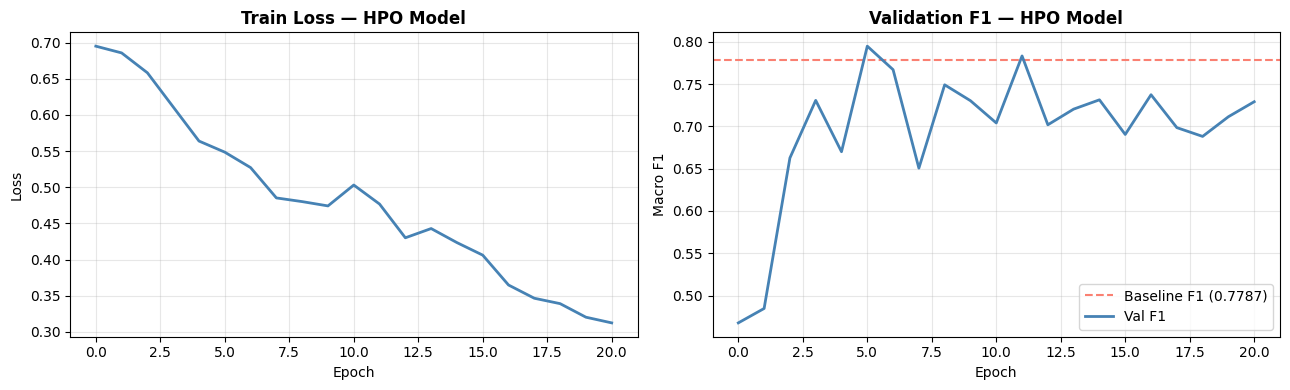

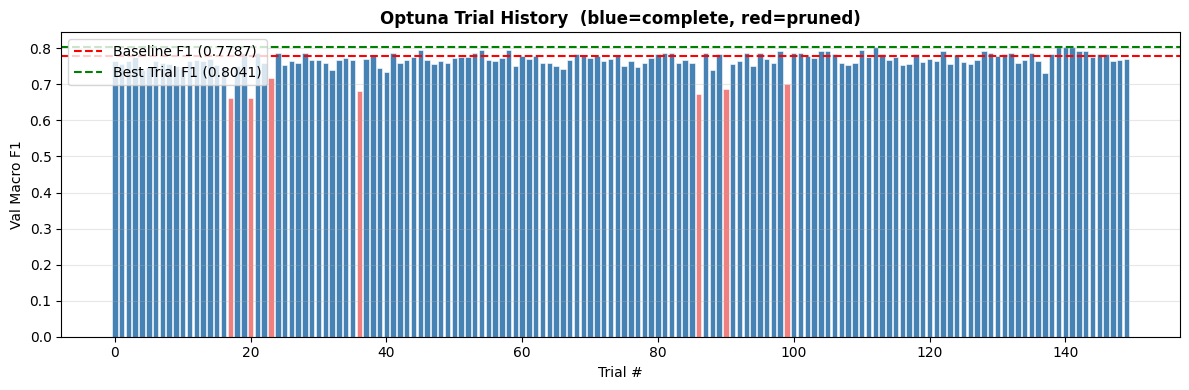

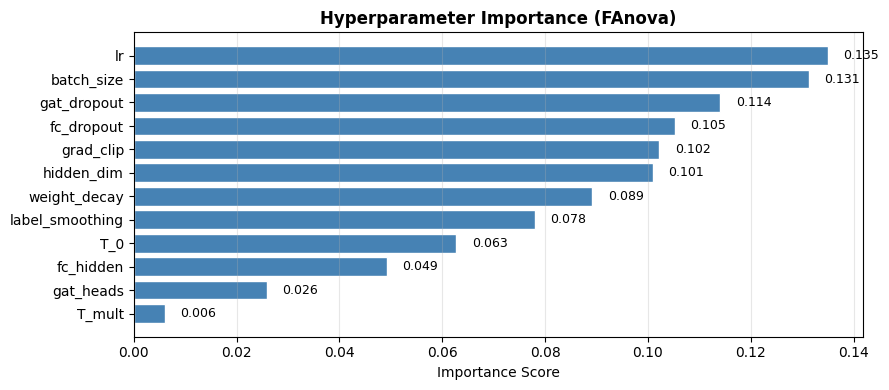


  HYPERPARAMETER COMPARISON: ORIGINAL vs BEST HPO
  Param                    Original     Best HPO
----------------------------------------------------------
  hidden_dim                    256          192  ◀
  gat_heads                       8            8
  gat_dropout                   0.6          0.5  ◀
  fc_dropout                    0.6          0.4  ◀
  fc_hidden                     128          128
  lr                          5e-05 0.0001328224192786923  ◀
  weight_decay               0.0001 1.532466436213218e-05  ◀
  T_0                            10           10
  T_mult                          2            2
  batch_size                     64           32  ◀
  label_smoothing               0.0         0.15  ◀
  grad_clip                    none          1.0  ◀

  SCORE COMPARISON: BASELINE vs AFTER HPO
  Metric           Baseline  After HPO     Change
-----------------------------------------------------------------
  Accuracy           0.7788     0.7885  ▲ +0.0097
  

In [ ]:
# ===============================
# 20. Visualisations
# ===============================
import matplotlib.pyplot as plt

# ── 1. Training curves ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(train_losses, color='steelblue', lw=2)
ax1.set_title('Train Loss — HPO Model', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)

ax2.axhline(0.7787, color='salmon', ls='--', lw=1.5, label='Baseline F1 (0.7787)')
ax2.plot(val_f1s, color='steelblue', lw=2, label='Val F1')
ax2.set_title('Validation F1 — HPO Model', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
try:
    plt.savefig(os.path.join(BASE_PATH, 'hpo_training_curves.png'), dpi=150)
except Exception as _e:
    print(f'[WARN] Could not save plot: {_e}')
plt.show()

# ── 2. Optuna trial history ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
vals   = [t.value if t.value is not None else 0 for t in study.trials]
states = [t.state.name for t in study.trials]
colors = ['steelblue' if s == 'COMPLETE' else 'lightcoral' for s in states]
ax.bar(range(len(vals)), vals, color=colors, edgecolor='white', lw=0.4)
ax.axhline(0.7787, color='red',   ls='--', lw=1.5, label='Baseline F1 (0.7787)')
ax.axhline(study.best_value, color='green', ls='--', lw=1.5,
           label=f'Best Trial F1 ({study.best_value:.4f})')
ax.set_xlabel('Trial #'); ax.set_ylabel('Val Macro F1')
ax.set_title('Optuna Trial History  (blue=complete, red=pruned)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
try:
    plt.savefig(os.path.join(BASE_PATH, 'hpo_trial_history.png'), dpi=150)
except Exception as _e:
    print(f'[WARN] Could not save plot: {_e}')
plt.show()

# ── 3. Parameter importance ───────────────────────────────────────────────────
try:
    from optuna.importance import get_param_importances
    imp    = get_param_importances(study)
    params = list(imp.keys())[::-1]
    vals_i = [imp[p] for p in params]
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(params, vals_i, color='steelblue', edgecolor='white')
    for bar, v in zip(bars, vals_i):
        ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)
    ax.set_xlabel('Importance Score')
    ax.set_title('Hyperparameter Importance (FAnova)', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    try:
        plt.savefig(os.path.join(BASE_PATH, 'hpo_param_importance.png'), dpi=150)
    except Exception as _e:
        print(f'[WARN] Could not save plot: {_e}')
    plt.show()
except Exception as e:
    print(f"[INFO] Importance plot skipped: {e}")

# ── 4. Hyperparameter comparison table ───────────────────────────────────────
print()
print("=" * 58)
print("  HYPERPARAMETER COMPARISON: ORIGINAL vs BEST HPO")
print("=" * 58)
orig = dict(hidden_dim=256, gat_heads=8, gat_dropout=0.60, fc_dropout=0.60,
            fc_hidden=128, lr=5e-5, weight_decay=1e-4, T_0=10, T_mult=2,
            batch_size=64, label_smoothing=0.0, grad_clip='none')
print(f"  {'Param':<20} {'Original':>12} {'Best HPO':>12}")
print("-" * 58)
for k, ov in orig.items():
    tv = study.best_params.get(k, 'N/A')
    changed = '  ◀' if str(ov) != str(tv) else ''
    print(f"  {k:<20} {str(ov):>12} {str(tv):>12}{changed}")
print("=" * 58)

# ── 5. Final score comparison ─────────────────────────────────────────────────
print()
print("=" * 65)
print("  SCORE COMPARISON: BASELINE vs AFTER HPO")
print("=" * 65)
print(f"  {'Metric':<14} {'Baseline':>10} {'After HPO':>10} {'Change':>10}")
print("-" * 65)
for metric, base, tuned in [
    ('Accuracy',   0.7788, best_test_acc),
    ('F1 (macro)', 0.7787, best_test_f1),
    ('Precision',  0.7798, best_test_prec),
    ('Recall',     0.7788, best_test_rec),
    ('ROC-AUC',    0.8147, best_test_auc),
]:
    delta = tuned - base
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '─')
    print(f"  {metric:<14} {base:>10.4f} {tuned:>10.4f}  {arrow} {delta:>+.4f}")
print("=" * 65)
avg_imp = ((best_test_acc-0.7788) + (best_test_f1-0.7787) +
           (best_test_prec-0.7798) + (best_test_rec-0.7788) +
           (best_test_auc-0.8147)) / 5
print(f"  Avg improvement across 5 metrics : {avg_imp:>+.4f}")
print("=" * 65)

In [ ]:
# ===============================
# 21. Ablation Study — Setup & Helpers
#     Defines all shared utilities used by cells 22-26:
#       - Edge index presets  (graph structure variants)
#       - _zero_modality()    (zero-out modalities)
#       - _custom_edges()     (swap graph edges)
#       - _loaders()          (build DataLoaders)
#       - run_ablation()      (train + evaluate one config)
#       - print_table()       (pretty results table)
#       - plot_group()        (bar chart for one group)
#     All experiments reuse best HPO params from Cell 19 (bp, study).
# ===============================
import copy, time
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch_geometric.loader import DataLoader
from torch_geometric.data   import Data as _Data
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score, roc_auc_score)

ABLATION_EPOCHS   = 100
ABLATION_PATIENCE = 15
ABLATION_SEED     = BEST_SEED      # ← use best seed found in Cell 19 Phase 1

# ── Updated baseline — your actual Cell 15 test scores ───────────────────────
BASELINE = dict(
    acc  = best_test_acc,
    f1   = best_test_f1,
    prec = best_test_prec,
    rec  = best_test_rec,
    auc  = best_test_auc,
)
FULL_MODEL_KEY = "Full Model (all 4 modalities)"
METRIC_KEYS    = ['acc', 'f1', 'prec', 'rec', 'auc']
bp             = study.best_params   # from Cell 18

# ── Edge index presets ────────────────────────────────────────────────────────
def _ei(pairs):
    return torch.tensor(pairs, dtype=torch.long).t().contiguous()

TRIANGLE   = [[0,1],[1,0],[0,2],[2,0],[1,2],[2,1]]
CTX_STAR   = [[3,0],[0,3],[3,1],[1,3],[3,2],[2,3]]
SELF_LOOPS = [[0,0],[1,1],[2,2],[3,3]]
ALL_PAIRS  = [[i,j] for i in range(4) for j in range(4)]

EI_FULL        = _ei(TRIANGLE + CTX_STAR + SELF_LOOPS)
EI_NO_SELF     = _ei(TRIANGLE + CTX_STAR)
EI_NO_CTX_STAR = _ei(TRIANGLE + SELF_LOOPS)
EI_NO_TRIANGLE = _ei(CTX_STAR + SELF_LOOPS)
EI_FULLY_CONN  = _ei(ALL_PAIRS)
EI_NO_GRAPH    = _ei([[0,0],[1,1],[2,2],[3,3]])

# ── Data helpers ──────────────────────────────────────────────────────────────
def _zero_modality(data_list, zero_text=False, zero_audio=False,
                   zero_video=False, zero_context=False):
    out = []
    for d in data_list:
        nd = _Data(edge_index=d.edge_index.clone(), y=d.y.clone())
        nd.text    = torch.zeros_like(d.text)    if zero_text    else d.text.clone()
        nd.audio   = torch.zeros_like(d.audio)   if zero_audio   else d.audio.clone()
        nd.video   = torch.zeros_like(d.video)   if zero_video   else d.video.clone()
        nd.context = torch.zeros_like(d.context) if zero_context else d.context.clone()
        nd.num_nodes = 4
        out.append(nd)
    return out

def _custom_edges(data_list, ei_tensor):
    out = []
    for d in data_list:
        nd = _Data(edge_index=ei_tensor.clone(), y=d.y.clone())
        nd.text    = d.text.clone();    nd.audio   = d.audio.clone()
        nd.video   = d.video.clone();   nd.context = d.context.clone()
        nd.num_nodes = 4
        out.append(nd)
    return out

def _loaders(tr_list, vl_list, ts_list):
    bs = bp['batch_size']
    g  = torch.Generator()
    g.manual_seed(ABLATION_SEED)
    return (DataLoader(tr_list, batch_size=bs, shuffle=True,  generator=g),
            DataLoader(vl_list, batch_size=bs, shuffle=False),
            DataLoader(ts_list, batch_size=bs, shuffle=False))

def _make_model(disable_self_loops=False):
    m = SarcasmGATv2Tunable(
        t_dim=t_features.shape[1], a_dim=a_features.shape[1],
        v_dim=v_features.shape[1], c_dim=c_features.shape[1],
        hidden_dim  = bp['hidden_dim'],  gat_heads   = bp['gat_heads'],
        gat_dropout = bp['gat_dropout'], fc_dropout  = bp['fc_dropout'],
        fc_hidden   = bp['fc_hidden'],
    ).to(DEVICE)
    if disable_self_loops:
        m.gat1.add_self_loops = False
        m.gat2.add_self_loops = False
    return m


def run_ablation(name, tr_dl, vl_dl, ts_dl,
                 label_smoothing=None, grad_clip=None,
                 use_scheduler=True, disable_self_loops=False):
    ls = bp['label_smoothing'] if label_smoothing is None else label_smoothing
    gc = bp['grad_clip']       if grad_clip       is None else grad_clip

    torch.manual_seed(ABLATION_SEED)
    torch.cuda.manual_seed(ABLATION_SEED)
    torch.cuda.manual_seed_all(ABLATION_SEED)
    np.random.seed(ABLATION_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    model = _make_model(disable_self_loops=disable_self_loops)

    decay_p, no_decay_p = [], []
    for pname, param in model.named_parameters():
        if not param.requires_grad: continue
        (no_decay_p if any(k in pname for k in ['bias','LayerNorm'])
         else decay_p).append(param)

    opt  = torch.optim.AdamW(
        [{'params': decay_p,    'weight_decay': bp['weight_decay']},
         {'params': no_decay_p, 'weight_decay': 0.0}], lr=bp['lr'])
    sch  = (torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                opt, T_0=bp['T_0'], T_mult=bp['T_mult'])
            if use_scheduler else None)
    crit = SmoothBCE(smoothing=ls)

    best_val_f1, best_state, patience_cnt = 0.0, None, 0
    for epoch in range(1, ABLATION_EPOCHS + 1):
        model.train()
        for data in tr_dl:
            data = data.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(data), data.y.view(-1))
            loss.backward()
            if gc is not None and gc != float('inf'):
                torch.nn.utils.clip_grad_norm_(model.parameters(), gc)
            opt.step()
        if sch: sch.step(epoch)

        _, val_f1, _, _, _ = get_metrics(model, vl_dl)
        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            best_state   = copy.deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= ABLATION_PATIENCE:
            break

    if best_state: model.load_state_dict(best_state)
    acc, f1, prec, rec, auc = get_metrics(model, ts_dl)
    del model; torch.cuda.empty_cache()
    return dict(name=name, acc=acc, f1=f1, prec=prec, rec=rec, auc=auc)

# ── Display helpers ───────────────────────────────────────────────────────────
def print_table(results, title):
    results_s = sorted(results, key=lambda x: x['f1'], reverse=True)
    print()
    print("=" * 95)
    print(f"  {title}")
    print("=" * 95)
    print(f"  {'Variant':<38} {'Acc':>7} {'F1':>7} {'Prec':>7} {'Rec':>7} {'AUC':>7} {'ΔF1':>9}")
    print("-" * 95)
    print(f"  {'[Baseline GATv2]':<38} {BASELINE['acc']:>7.4f} {BASELINE['f1']:>7.4f} "
          f"{BASELINE['prec']:>7.4f} {BASELINE['rec']:>7.4f} {BASELINE['auc']:>7.4f}  {'—':>7}")
    print("-" * 95)
    for r in results_s:
        df   = r['f1'] - BASELINE['f1']
        sym  = '▲' if df >= 0 else '▼'
        star = ' ★' if r['name'] == FULL_MODEL_KEY else ''
        print(f"  {r['name']+star:<38} {r['acc']:>7.4f} {r['f1']:>7.4f} "
              f"{r['prec']:>7.4f} {r['rec']:>7.4f} {r['auc']:>7.4f}  "
              f"{sym}{abs(df):>7.4f}")
    print("=" * 95)

def plot_group(results, title, color, save_name):
    results_s = sorted(results, key=lambda x: x['f1'], reverse=True)
    names = [r['name'] + (' ★' if r['name'] == FULL_MODEL_KEY else '')
             for r in results_s]
    f1s  = [r['f1']  for r in results_s]
    accs = [r['acc'] for r in results_s]
    aucs = [r['auc'] for r in results_s]
    x = np.arange(len(names)); w = 0.28

    fig, ax = plt.subplots(figsize=(max(10, len(names)*1.3), 5))
    b1 = ax.bar(x-w, f1s,  w, label='F1',      color=color, alpha=0.90, edgecolor='white')
    b2 = ax.bar(x,   accs, w, label='Accuracy', color=color, alpha=0.55, edgecolor='white', hatch='//')
    b3 = ax.bar(x+w, aucs, w, label='AUC',      color=color, alpha=0.35, edgecolor='white', hatch='xx')

    ax.axhline(BASELINE['f1'],  color='crimson',    ls='--', lw=1.5,
               label=f"Baseline F1 ({BASELINE['f1']:.4f})")
    ax.axhline(BASELINE['auc'], color='darkorange', ls=':',  lw=1.2,
               label=f"Baseline AUC ({BASELINE['auc']:.4f})")

    for bar, r in zip(b1, results_s):
        df  = r['f1'] - BASELINE['f1']
        col = 'darkgreen' if df >= 0 else 'darkred'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f"{r['f1']:.4f}\n({df:+.3f})",
                ha='center', va='bottom', fontsize=7.5, color=col, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Score'); ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylim(max(0, min(f1s+accs+aucs)-0.07), max(f1s+accs+aucs)+0.09)
    ax.legend(fontsize=8, loc='lower right', ncol=2)
    ax.grid(axis='y', alpha=0.3, ls='--')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    try:
        plt.savefig(os.path.join(BASE_PATH, save_name), dpi=150, bbox_inches='tight')
        print(f"Saved → {save_name}")
    except Exception as e:
        print(f"[WARN] {e}")
    plt.show()

# ── Global results collector ──────────────────────────────────────────────────
all_ablation_results = []

print("Ablation setup complete. Helpers loaded.")
print(f"  HPO best params  : {bp}")
print(f"  Ablation seed    : {ABLATION_SEED}  (best seed from Cell 19)")
print(f"  ABLATION_EPOCHS  : {ABLATION_EPOCHS}  |  PATIENCE : {ABLATION_PATIENCE}")
print(f"  Baseline         : F1={BASELINE['f1']:.4f}  Acc={BASELINE['acc']:.4f}  "
      f"Prec={BASELINE['prec']:.4f}  Rec={BASELINE['rec']:.4f}  AUC={BASELINE['auc']:.4f}")

Ablation setup complete. Helpers loaded.
  HPO best params  : {'hidden_dim': 192, 'gat_heads': 8, 'fc_hidden': 128, 'gat_dropout': 0.5, 'fc_dropout': 0.4, 'label_smoothing': 0.15, 'weight_decay': 1.532466436213218e-05, 'lr': 0.0001328224192786923, 'T_0': 10, 'T_mult': 2, 'grad_clip': 1.0, 'batch_size': 32}
  Ablation seed    : 42  (best seed from Cell 19)
  ABLATION_EPOCHS  : 100  |  PATIENCE : 15
  Baseline         : F1=0.7833  Acc=0.7885  Prec=0.8186  Rec=0.7885  AUC=0.8499


In [ ]:
# ===============================
# 22. Ablation A — Modality Ablation
#     15 experiments:
#       - Full model (all 4 modalities)
#       - Remove one modality at a time  (4 variants)
#       - Single modality only           (4 variants)
#       - All two-modality pairs         (6 variants)
# ===============================
print("=" * 60)
print("  GROUP A — MODALITY ABLATION  (15 experiments)")
print(f"  Seed : {ABLATION_SEED}  |  Baseline F1 : {BASELINE['f1']:.4f}")
print("=" * 60)

modality_results = []
experiments_A    = []

# Full model
experiments_A.append((FULL_MODEL_KEY,
    _loaders(HPO_TRAIN, HPO_VAL, HPO_TEST), {}))

# Remove one modality
for kw, label in [
    (dict(zero_text=True),    "w/o Text"),
    (dict(zero_audio=True),   "w/o Audio"),
    (dict(zero_video=True),   "w/o Video"),
    (dict(zero_context=True), "w/o Context"),
]:
    experiments_A.append((label, _loaders(
        _zero_modality(HPO_TRAIN, **kw),
        _zero_modality(HPO_VAL,   **kw),
        _zero_modality(HPO_TEST,  **kw)), {}))

# Single modality only
for kw, label in [
    (dict(zero_audio=True,  zero_video=True,   zero_context=True), "Text only"),
    (dict(zero_text=True,   zero_video=True,   zero_context=True), "Audio only"),
    (dict(zero_text=True,   zero_audio=True,   zero_context=True), "Video only"),
    (dict(zero_text=True,   zero_audio=True,   zero_video=True),   "Context only"),
]:
    experiments_A.append((label, _loaders(
        _zero_modality(HPO_TRAIN, **kw),
        _zero_modality(HPO_VAL,   **kw),
        _zero_modality(HPO_TEST,  **kw)), {}))

# Two-modality pairs
for kw, label in [
    (dict(zero_video=True,   zero_context=True), "Text + Audio"),
    (dict(zero_audio=True,   zero_context=True), "Text + Video"),
    (dict(zero_audio=True,   zero_video=True),   "Text + Context"),
    (dict(zero_text=True,    zero_context=True), "Audio + Video"),
    (dict(zero_text=True,    zero_video=True),   "Audio + Context"),
    (dict(zero_text=True,    zero_audio=True),   "Video + Context"),
]:
    experiments_A.append((label, _loaders(
        _zero_modality(HPO_TRAIN, **kw),
        _zero_modality(HPO_VAL,   **kw),
        _zero_modality(HPO_TEST,  **kw)), {}))

print(f"Running {len(experiments_A)} experiments...\n")
t0 = time.time()
for idx, (name, (tr_dl, vl_dl, ts_dl), kw) in enumerate(experiments_A):
    print(f"  [{idx+1:02d}/{len(experiments_A)}] {name} ...", end=" ", flush=True)
    r = run_ablation(name, tr_dl, vl_dl, ts_dl, **kw)
    r['group'] = 'A'
    modality_results.append(r)
    all_ablation_results.append(r)
    df  = r['f1'] - BASELINE['f1']
    sym = '▲' if df >= 0 else '▼'
    print(f"F1={r['f1']:.4f} ({sym}{abs(df):.4f})")

print(f"\nDone in {(time.time()-t0)/60:.1f} min.")

# ── Table ─────────────────────────────────────────────────────────────────────
print_table(modality_results, "A — MODALITY ABLATION RESULTS")

# ── Findings ──────────────────────────────────────────────────────────────────
full_r        = next(r for r in modality_results if r['name'] == FULL_MODEL_KEY)
wout          = [r for r in modality_results if r['name'].startswith('w/o')]
single        = [r for r in modality_results if r['name'].endswith('only')]
most_critical = min(wout, key=lambda x: x['f1'])
least_critical= max(wout, key=lambda x: x['f1'])
best_single   = max(single, key=lambda x: x['f1'])

print()
print("  KEY FINDINGS (Modality):")
print(f"    Full model F1         : {full_r['f1']:.4f}")
print(f"    Most critical modality: {most_critical['name']}  "
      f"(removal drops F1 by {full_r['f1']-most_critical['f1']:.4f})")
print(f"    Least critical        : {least_critical['name']}  "
      f"(removal drops F1 by {full_r['f1']-least_critical['f1']:.4f})")
print(f"    Best single modality  : {best_single['name']}  F1={best_single['f1']:.4f}")

  GROUP A — MODALITY ABLATION  (15 experiments)
  Seed : 42  |  Baseline F1 : 0.7833
Running 15 experiments...

  [01/15] Full Model (all 4 modalities) ... F1=0.7833 (▲0.0000)
  [02/15] w/o Text ... F1=0.7753 (▼0.0080)
  [03/15] w/o Audio ... F1=0.7691 (▼0.0142)
  [04/15] w/o Video ... F1=0.6791 (▼0.1042)
  [05/15] w/o Context ... F1=0.7098 (▼0.0735)
  [06/15] Text only ... F1=0.5763 (▼0.2070)
  [07/15] Audio only ... F1=0.6700 (▼0.1133)
  [08/15] Video only ... F1=0.7499 (▼0.0334)
  [09/15] Context only ... F1=0.6061 (▼0.1773)
  [10/15] Text + Audio ... F1=0.6279 (▼0.1555)
  [11/15] Text + Video ... F1=0.7211 (▼0.0622)
  [12/15] Text + Context ... 

KeyboardInterrupt: 

In [ ]:
# ===============================
# 23. Ablation B — Graph Structure Ablation
#     6 experiments — varying which edge types are present:
#       Full Graph (default) / No Self-Loops /
#       No Context-Star / No Modality-Triangle /
#       Fully Connected / No Graph (self-loops only)
# ===============================
print("=" * 60)
print("  GROUP B — GRAPH STRUCTURE ABLATION  (6 experiments)")
print(f"  Seed : {ABLATION_SEED}  |  Baseline F1 : {BASELINE['f1']:.4f}")
print("=" * 60)

graph_results = []

# ── disable_self_loops=True for configs that have no self-loops in edge index ─
experiments_B = [
    ("Full Graph (default)",       EI_FULL,        {}),
    ("No Self-Loops",              EI_NO_SELF,     {'disable_self_loops': True}),
    ("No Context-Star Edges",      EI_NO_CTX_STAR, {}),
    ("No Modality-Triangle Edges", EI_NO_TRIANGLE, {}),
    ("Fully Connected Graph",      EI_FULLY_CONN,  {}),
    ("No Graph (self-loops only)", EI_NO_GRAPH,    {'disable_self_loops': True}),
]

print(f"Running {len(experiments_B)} experiments...\n")
t0 = time.time()
for idx, (name, ei_tensor, kw) in enumerate(experiments_B):
    print(f"  [{idx+1}/{len(experiments_B)}] {name} ...", end=" ", flush=True)
    tr_dl, vl_dl, ts_dl = _loaders(
        _custom_edges(HPO_TRAIN, ei_tensor),
        _custom_edges(HPO_VAL,   ei_tensor),
        _custom_edges(HPO_TEST,  ei_tensor))
    r = run_ablation(name, tr_dl, vl_dl, ts_dl, **kw)
    r['group'] = 'B'
    graph_results.append(r)
    all_ablation_results.append(r)
    df  = r['f1'] - BASELINE['f1']
    sym = '▲' if df >= 0 else '▼'
    print(f"F1={r['f1']:.4f} ({sym}{abs(df):.4f})")

print(f"\nDone in {(time.time()-t0)/60:.1f} min.")

# ── Table ─────────────────────────────────────────────────────────────────────
print_table(graph_results, "B — GRAPH STRUCTURE ABLATION RESULTS")

# ── Findings ──────────────────────────────────────────────────────────────────
full_g     = next(r for r in graph_results if 'default'         in r['name'])
no_graph   = next(r for r in graph_results if 'self-loops only' in r['name'])
graph_gain = full_g['f1'] - no_graph['f1']

print()
print("  KEY FINDINGS (Graph Structure):")
print(f"    Full graph F1          : {full_g['f1']:.4f}")
print(f"    Gain from graph vs none: {graph_gain:+.4f}  "
      f"({'graph helps' if graph_gain > 0 else 'graph hurts'})")

best_g  = max(graph_results, key=lambda x: x['f1'])
worst_g = min(graph_results, key=lambda x: x['f1'])
print(f"    Best  graph config     : {best_g['name']}  F1={best_g['f1']:.4f}")
print(f"    Worst graph config     : {worst_g['name']}  F1={worst_g['f1']:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
plot_group(graph_results, "B — Graph Structure Ablation", '#55A868', 'ablation_B_graph.png')

In [ ]:
# ===============================
# 24. Ablation C — Training Tricks Ablation
#     5 experiments — removing training-time improvements:
#       No Label Smoothing / No Grad Clipping /
#       No LR Scheduler / No Smoothing+No Clip /
#       No Smoothing+No Scheduler
# ===============================
print("=" * 60)
print("  GROUP C — TRAINING TRICKS ABLATION  (5 experiments)")
print(f"  Seed : {ABLATION_SEED}  |  Baseline F1 : {BASELINE['f1']:.4f}")
print("=" * 60)

trick_results = []
experiments_C = [
    ("No Label Smoothing",
     dict(label_smoothing=0.0)),
    ("No Grad Clipping",
     dict(grad_clip=float('inf'))),
    ("No LR Scheduler",
     dict(use_scheduler=False)),
    ("No Smoothing + No Grad Clip",
     dict(label_smoothing=0.0, grad_clip=float('inf'))),
    ("No Smoothing + No Scheduler",
     dict(label_smoothing=0.0, use_scheduler=False)),
]

print(f"Running {len(experiments_C)} experiments...\n")
t0 = time.time()
tr_dl, vl_dl, ts_dl = _loaders(HPO_TRAIN, HPO_VAL, HPO_TEST)

for idx, (name, kw) in enumerate(experiments_C):
    print(f"  [{idx+1}/{len(experiments_C)}] {name} ...", end=" ", flush=True)
    r = run_ablation(name, tr_dl, vl_dl, ts_dl, **kw)
    r['group'] = 'C'
    trick_results.append(r)
    all_ablation_results.append(r)
    df  = r['f1'] - BASELINE['f1']
    sym = '▲' if df >= 0 else '▼'
    print(f"F1={r['f1']:.4f} ({sym}{abs(df):.4f})")

print(f"\nDone in {(time.time()-t0)/60:.1f} min.")

# ── Table ─────────────────────────────────────────────────────────────────────
print_table(trick_results, "C — TRAINING TRICKS ABLATION RESULTS")

# ── Findings ──────────────────────────────────────────────────────────────────
full_ref = next((r for r in all_ablation_results
                 if r['name'] == FULL_MODEL_KEY), None)

print()
print("  KEY FINDINGS (Training Tricks):")
if full_ref:
    for r in trick_results:
        df = r['f1'] - full_ref['f1']
        print(f"    Removing {r['name']:<30}: ΔF1={df:+.4f}")
most_important = min(trick_results, key=lambda x: x['f1'])
print(f"    Most important trick  : removing '{most_important['name']}'  "
      f"drops F1 by {full_ref['f1']-most_important['f1']:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
plot_group(trick_results, "C — Training Tricks Ablation", '#C44E52', 'ablation_C_tricks.png')

In [ ]:
# ===============================
# 25. Ablation — Combined Summary Table
#     Ranks ALL experiments across groups A, B, C by F1.
#     Also shows per-group best and key takeaways.
# ===============================
print("=" * 100)
print("  COMPLETE ABLATION RANKING  (all experiments, sorted by F1 descending)")
print("=" * 100)
print(f"  {'#':>3}  {'Grp':>4}  {'Variant':<38} {'Acc':>7} {'F1':>7} "
      f"{'Prec':>7} {'Rec':>7} {'AUC':>7} {'ΔF1':>9}")
print("-" * 100)

sorted_all = sorted(all_ablation_results, key=lambda x: x['f1'], reverse=True)
for rank, r in enumerate(sorted_all, 1):
    df   = r['f1'] - BASELINE['f1']
    sym  = '▲' if df >= 0 else '▼'
    star = ' ★' if r['name'] == FULL_MODEL_KEY else ''
    print(f"  {rank:>3}  [{r['group']}]  {r['name']+star:<38} "
          f"{r['acc']:>7.4f} {r['f1']:>7.4f} {r['prec']:>7.4f} "
          f"{r['rec']:>7.4f} {r['auc']:>7.4f}  {sym}{abs(df):>7.4f}")

print("=" * 100)

# ── Per-group bests ───────────────────────────────────────────────────────────
print()
print("  PER-GROUP BEST CONFIGURATIONS:")
print(f"  {'Group':<6} {'Best Variant':<38} {'F1':>7} {'ΔF1 vs HPO baseline':>20}")
print("-" * 75)
for grp, label in [('A','Modality'), ('B','Graph'), ('C','Training')]:
    grp_r = [r for r in all_ablation_results if r['group'] == grp]
    best  = max(grp_r, key=lambda x: x['f1'])
    df    = best['f1'] - BASELINE['f1']
    sym   = '▲' if df >= 0 else '▼'
    print(f"  [{grp}] {label:<5}  {best['name']:<38} {best['f1']:>7.4f}  "
          f"{sym}{abs(df):>7.4f}")

# ── Overall summary ───────────────────────────────────────────────────────────
best_overall   = max(all_ablation_results, key=lambda x: x['f1'])
worst_overall  = min(all_ablation_results, key=lambda x: x['f1'])
full_r         = next(r for r in all_ablation_results
                      if r['name'] == FULL_MODEL_KEY)
beats_baseline = [r for r in all_ablation_results
                  if r['f1'] > BASELINE['f1']]

print()
print("=" * 75)
print("  OVERALL SUMMARY")
print("=" * 75)
print(f"  Total experiments     : {len(all_ablation_results)}")
print(f"  HPO baseline F1       : {BASELINE['f1']:.4f}")
print(f"  Full model F1         : {full_r['f1']:.4f}  "
      f"(ΔF1={full_r['f1']-BASELINE['f1']:+.4f})")
print(f"  Best overall          : {best_overall['name']}  "
      f"F1={best_overall['f1']:.4f}")
print(f"  Worst overall         : {worst_overall['name']}  "
      f"F1={worst_overall['f1']:.4f}")
print(f"  Configs beating HPO   : {len(beats_baseline)} / "
      f"{len(all_ablation_results)}")
print("=" * 75)

In [ ]:
# ===============================
# 26. Ablation — ΔF1 Heatmap (all experiments)
#     Horizontal bar chart showing ΔF1 vs baseline
#     for every ablation configuration, coloured by group.
#     Saved to Google Drive as ablation_delta_heatmap.png
# ===============================
import matplotlib.patches as mpatches

GROUP_COLORS = {'A': '#4C72B0', 'B': '#55A868', 'C': '#C44E52'}
GROUP_LABELS = {'A': 'Modality', 'B': 'Graph Structure', 'C': 'Training Tricks'}

sorted_all = sorted(all_ablation_results, key=lambda x: x['f1'], reverse=True)
names   = [r['name'] + (' ★' if r['name'] == FULL_MODEL_KEY else '')
           for r in sorted_all]
delta   = [r['f1'] - BASELINE['f1'] for r in sorted_all]
colors  = [GROUP_COLORS[r['group']] for r in sorted_all]
grp_lbl = [f"[{r['group']}]" for r in sorted_all]

fig, ax = plt.subplots(figsize=(9, max(7, len(sorted_all) * 0.40)))

bars = ax.barh(range(len(names)), delta,
               color=colors, edgecolor='white', lw=0.5, height=0.72)

ax.axvline(0, color='black', lw=1.2)
ax.axvline(0, color='black', lw=1.2)

for i, (bar, val, grp) in enumerate(zip(bars, delta, grp_lbl)):
    xpos = val + (0.001 if val >= 0 else -0.001)
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f"{val:+.4f}  {grp}",
            va='center', ha=ha, fontsize=8)

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8.5)
ax.set_xlabel('ΔF1 vs Baseline (GATv2)', fontsize=10)
ax.set_title('All Ablations — ΔF1 vs Baseline\n(★ = Full Model)',
             fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3, ls='--')
ax.spines[['top','right']].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=f"[{g}] {GROUP_LABELS[g]}")
                  for g, c in GROUP_COLORS.items()]
baseline_patch  = mpatches.Patch(color='white', ec='black', lw=1,
                                  label=f"Baseline F1 = {BASELINE['f1']:.4f}")
ax.legend(handles=legend_patches + [baseline_patch],
          fontsize=9, loc='lower right')

plt.tight_layout()
try:
    path = os.path.join(BASE_PATH, 'ablation_delta_heatmap.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"Saved → ablation_delta_heatmap.png")
except Exception as e:
    print(f"[WARN] {e}")
plt.show()
print("\n[Ablation Study Complete]")
